# Baseline Experiment Findings — AgenticCyOps

**Purpose:** Visualize and analyze the baseline experiment results across 6 validator groups (A-F), 4 domains (cyberops, healthcare, finance, legal), and 3 configurations (flat, acl_hardened, agenticcyops).

**Data source:** `results/baseline/group_{A-F}/{domain}/enhanced_baseline.csv` (35+ columns per row, 3 rows per file)

## Section 1: Setup & Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# ---------------------------------------------------------------------------
# Professional plot style
# ---------------------------------------------------------------------------
sns.set_theme(style="whitegrid", font_scale=1.05, palette="muted")
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 140,
    "savefig.bbox": "tight",
    "font.family": "sans-serif",
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "figure.figsize": (12, 6),
    "legend.fontsize": 10,
})

# ---------------------------------------------------------------------------
# Colour scheme
# ---------------------------------------------------------------------------
CONFIG_COLORS = {
    "flat": "#e74c3c",
    "acl_hardened": "#f39c12",
    "agenticcyops": "#2ecc71",
}
CONFIG_LABELS = {"flat": "Flat MAS", "acl_hardened": "ACL-Hardened", "agenticcyops": "AgenticCyOps"}
CONFIGS = ["flat", "acl_hardened", "agenticcyops"]
GROUPS = list("ABCDEF")
DOMAINS = ["cyberops", "healthcare", "finance", "legal"]
PHASES = ["monitor", "analyze", "admin", "report"]

# ---------------------------------------------------------------------------
# Tool manifests (from component_registry.json counts)
# ---------------------------------------------------------------------------
TOOL_MANIFEST = {
    "cyberops":   {"monitor": 4, "analyze": 3, "admin": 5, "report": 4, "total": 16},
    "healthcare": {"monitor": 4, "analyze": 3, "admin": 3, "report": 3, "total": 13},
    "finance":    {"monitor": 4, "analyze": 3, "admin": 3, "report": 3, "total": 13},
    "legal":      {"monitor": 4, "analyze": 3, "admin": 3, "report": 3, "total": 13},
}

# Utility: add value labels on bars
def _bar_labels(ax, bars, fmt="{:.0f}", fontsize=9, offset=0.3):
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, h + offset,
                    fmt.format(h), ha="center", va="bottom",
                    fontsize=fontsize, fontweight="bold")

print("Setup complete.")

Setup complete.


In [2]:
# ---------------------------------------------------------------------------
# Load all enhanced_baseline.csv files into a single DataFrame
# ---------------------------------------------------------------------------
BASE = Path("<REPO_ROOT>")
frames = []
for g in GROUPS:
    for d in DOMAINS:
        csv_path = BASE / "results" / "baseline" / f"group_{g}" / d / "enhanced_baseline.csv"
        if csv_path.exists():
            tmp = pd.read_csv(csv_path)
            frames.append(tmp)
        else:
            print(f"  [skip] {csv_path.relative_to(BASE)} not found")

df = pd.concat(frames, ignore_index=True)
print(f"Loaded {len(df)} rows  x  {len(df.columns)} columns  "
      f"({df['group'].nunique()} groups, {df['domain'].nunique()} domains, "
      f"{df['config'].nunique()} configs)")
# Full preview: all 72 rows = 6 groups x 4 domains x 3 configs
with pd.option_context('display.max_rows', 80, 'display.max_columns', 10):
    preview = df[['group','domain','config','total_events','phases_completed',
                  'tool_calls_allowed','tool_calls_denied','total_fp_rate']] \
                 .sort_values(['group','domain','config']).reset_index(drop=True)
    display(preview)

Loaded 72 rows  x  62 columns  (6 groups, 4 domains, 3 configs)


,group,domain,config,total_events,phases_completed,tool_calls_allowed,tool_calls_denied,total_fp_rate
0,A,cyberops,acl_hardened,30,4,10,9,0.0000
1,A,cyberops,agenticcyops,107,4,11,0,0.0000
2,A,cyberops,flat,30,4,19,0,0.0000
3,A,finance,acl_hardened,30,4,17,2,0.0000
4,A,finance,agenticcyops,181,4,11,1,0.0833
5,A,finance,flat,27,4,16,0,0.0000
6,A,healthcare,acl_hardened,26,4,8,6,0.0000
7,A,healthcare,agenticcyops,171,4,12,2,0.1429
8,A,healthcare,flat,25,4,13,0,0.0000
9,A,legal,acl_hardened,23,4,8,4,0.0000


### Domain-specific FP rate per group (AgenticCyOps)

Grouped bar chart: four domains on the x-axis, one bar per model group (A-F) within each domain cluster. `flat` and `acl_hardened` carry 0% FP across all cells (they don't validate), so only AgenticCyOps is shown.

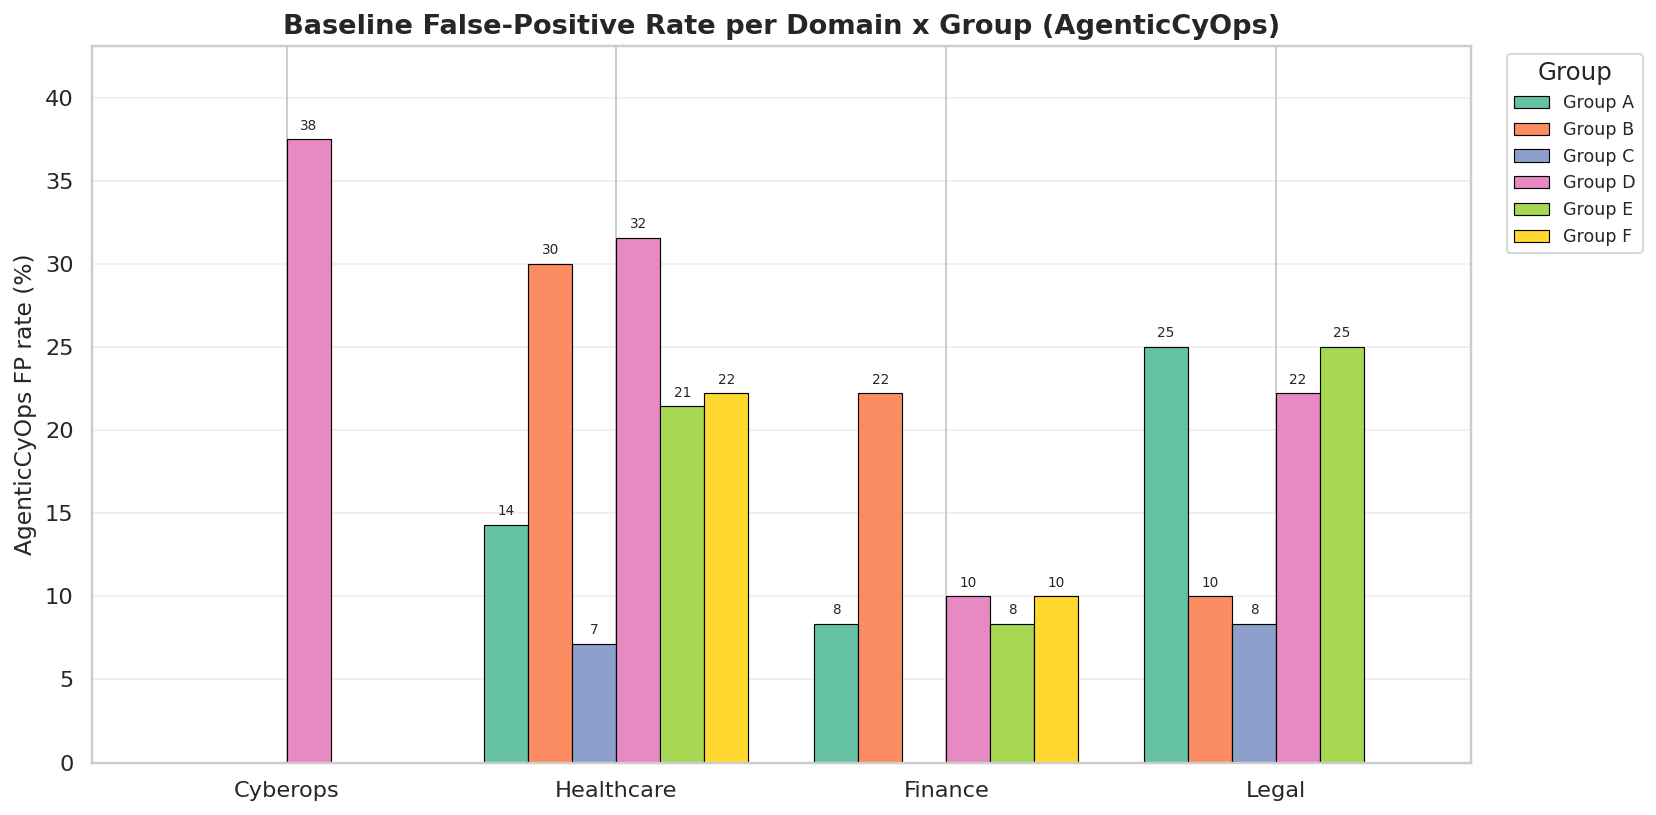

FP-rate pivot (%) -- domain x group:
group           A      B     C      D      E      F
domain                                             
cyberops     0.00   0.00  0.00  37.50   0.00   0.00
healthcare  14.29  30.00  7.14  31.58  21.43  22.22
finance      8.33  22.22  0.00  10.00   8.33  10.00
legal       25.00  10.00  8.33  22.22  25.00   0.00


In [3]:
# Chart 1.2: Domain-specific FP rate per group (AgenticCyOps only)
aco = df[df['config'] == 'agenticcyops'].copy()
aco['fp_pct'] = aco['total_fp_rate'] * 100

pivot = aco.pivot_table(index='domain', columns='group', values='fp_pct', aggfunc='mean') \
          .reindex(index=DOMAINS, columns=GROUPS)

fig, ax = plt.subplots(figsize=(12, 6))
n_groups = len(GROUPS)
n_domains = len(DOMAINS)
width = 0.8 / n_groups
x = np.arange(n_domains)
palette = sns.color_palette('Set2', n_groups)

for i, g in enumerate(GROUPS):
    offset = (i - (n_groups - 1) / 2) * width
    vals = pivot[g].values
    bars = ax.bar(x + offset, vals, width, label=f'Group {g}',
                  color=palette[i], edgecolor='black', linewidth=0.6)
    for b, v in zip(bars, vals):
        if not np.isnan(v) and v > 0:
            ax.text(b.get_x() + b.get_width() / 2, v + 0.4, f'{v:.0f}',
                    ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels([d.capitalize() for d in DOMAINS])
ax.set_ylabel('AgenticCyOps FP rate (%)')
ax.set_title('Baseline False-Positive Rate per Domain x Group (AgenticCyOps)', weight='bold')
ax.legend(title='Group', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.set_ylim(0, max(25, pivot.max().max() * 1.15 if not pivot.empty else 25))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('FP-rate pivot (%) -- domain x group:')
print(pivot.round(2))

## Section 2: Configuration Comparison Overview

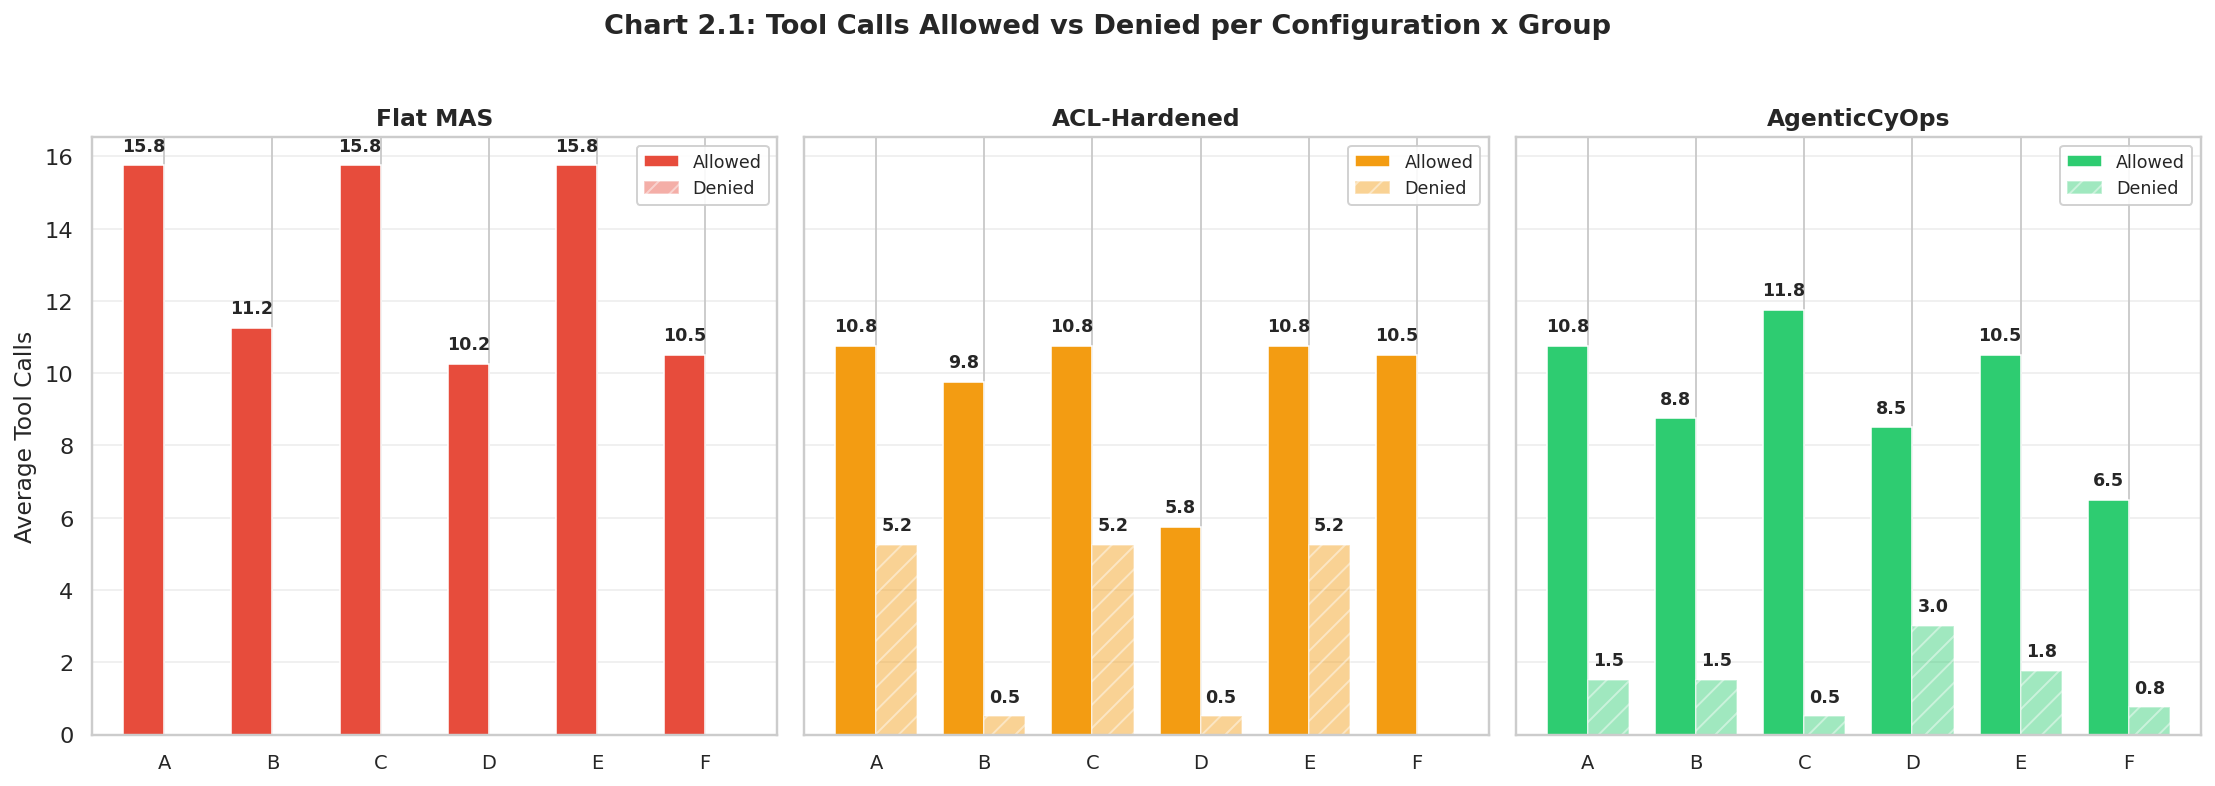

In [4]:
# Chart 2.1: Tool calls allowed vs denied per config x group
# (one subplot per config, bars per model group, averaged across domains)

agg = df.groupby(["config", "group"])[["tool_calls_allowed", "tool_calls_denied"]].mean()

fig, axes = plt.subplots(1, len(CONFIGS), figsize=(16, 5.5), sharey=True)
x = np.arange(len(GROUPS))
w = 0.38

for ax, cfg in zip(axes, CONFIGS):
    sub = agg.loc[cfg].reindex(GROUPS)
    b1 = ax.bar(x - w/2, sub["tool_calls_allowed"], w,
                label="Allowed", color=CONFIG_COLORS[cfg],
                edgecolor="white", linewidth=0.8)
    b2 = ax.bar(x + w/2, sub["tool_calls_denied"], w,
                label="Denied", color=CONFIG_COLORS[cfg],
                edgecolor="white", linewidth=0.8, alpha=0.45, hatch="//")
    _bar_labels(ax, b1, fmt="{:.1f}")
    _bar_labels(ax, b2, fmt="{:.1f}")
    ax.set_xticks(x)
    ax.set_xticklabels([f"{g}" for g in GROUPS], fontsize=10)
    ax.set_title(CONFIG_LABELS[cfg], fontsize=12, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)
    ax.legend(frameon=True, framealpha=0.9, fontsize=9, loc="upper right")

axes[0].set_ylabel("Average Tool Calls")
fig.suptitle("Chart 2.1: Tool Calls Allowed vs Denied per Configuration x Group",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


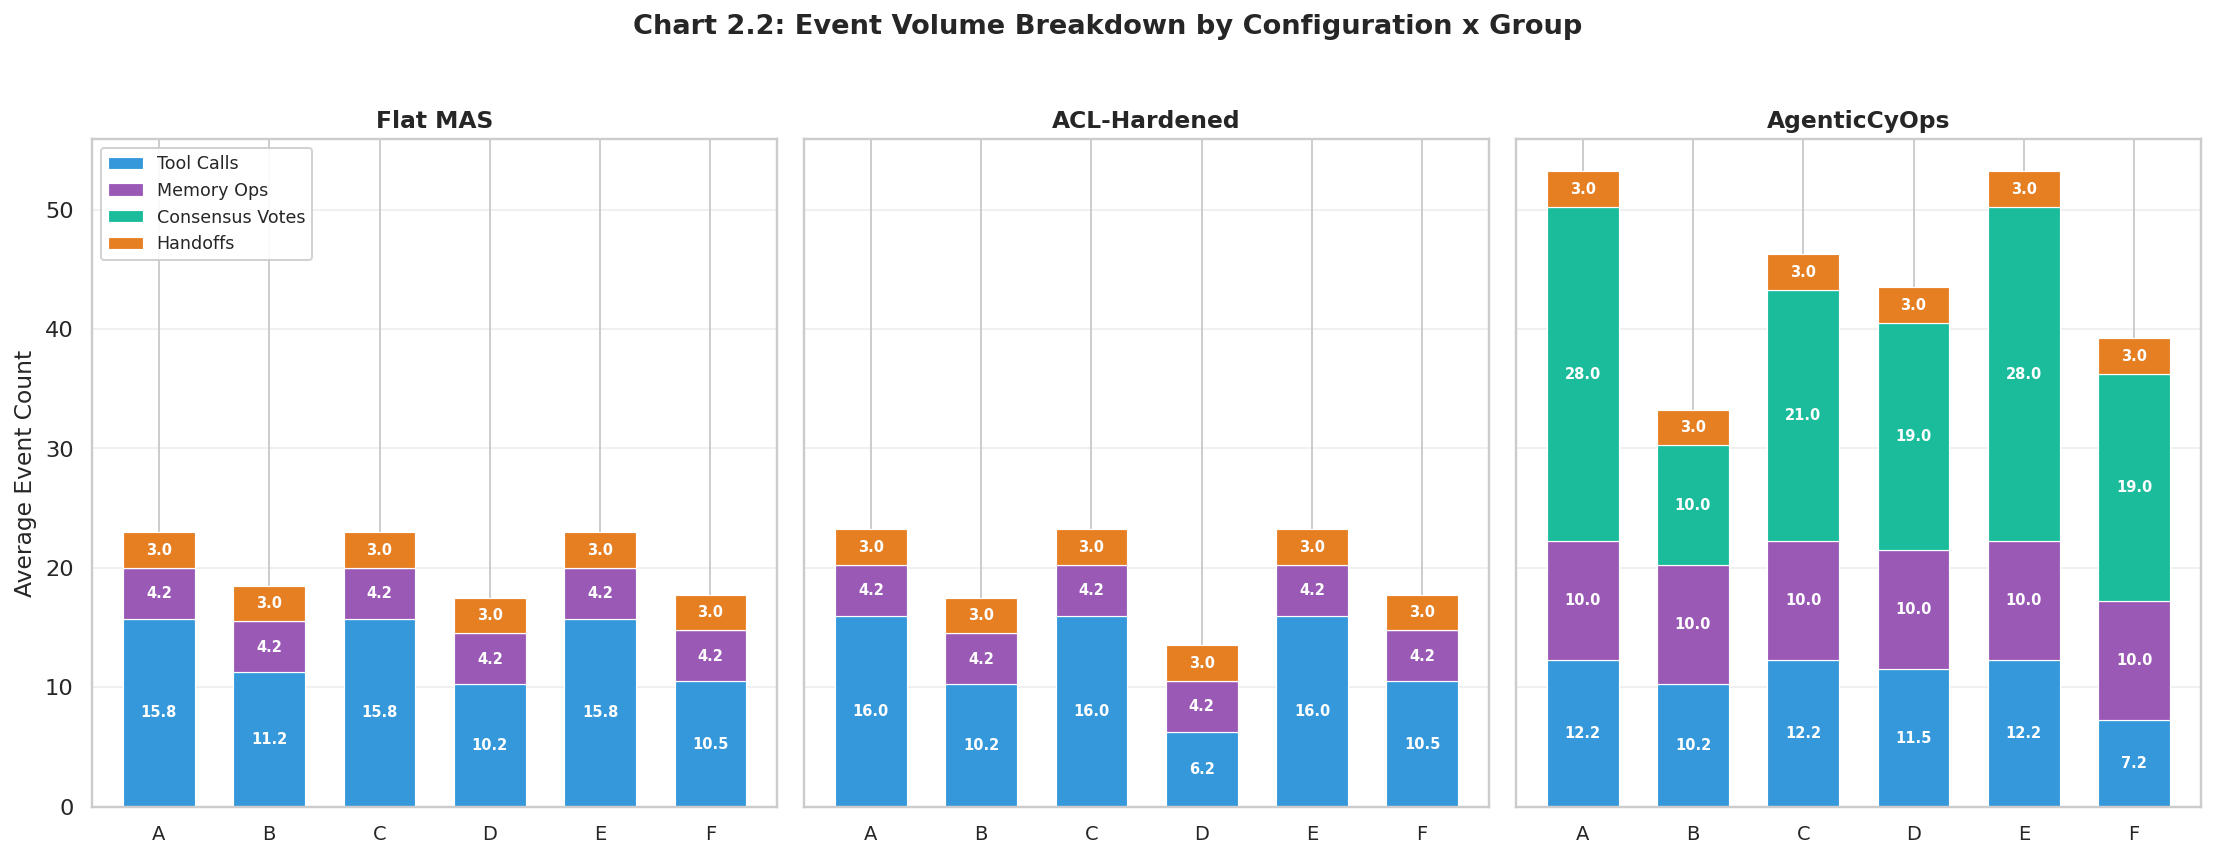

In [5]:
# Chart 2.2: Stacked bar — Event volume breakdown by config x group
# Categories: tool_calls_total, memory ops (reads+writes), consensus votes, handoffs (phases-1)

def _breakdown(gdf):
    return pd.Series({
        "tool_calls": gdf["tool_calls_total"].mean(),
        "memory_ops": (gdf["memory_reads"] + gdf["memory_writes"]).mean(),
        "consensus":  gdf["p3_consensus_votes"].mean(),
        "handoffs":   max(gdf["phases_completed"].mean() - 1, 0),
    })

breakdown = (df.groupby(["config", "group"]).apply(_breakdown, include_groups=False)
               .reindex([(c, g) for c in CONFIGS for g in GROUPS]))

fig, axes = plt.subplots(1, len(CONFIGS), figsize=(16, 6), sharey=True)
x = np.arange(len(GROUPS))
w = 0.65
categories = ["tool_calls", "memory_ops", "consensus", "handoffs"]
cat_colors = ["#3498db", "#9b59b6", "#1abc9c", "#e67e22"]
cat_labels = ["Tool Calls", "Memory Ops", "Consensus Votes", "Handoffs"]

for ax, cfg in zip(axes, CONFIGS):
    sub = breakdown.loc[cfg].reindex(GROUPS)
    bottom = np.zeros(len(GROUPS))
    for cat, color, label in zip(categories, cat_colors, cat_labels):
        vals = sub[cat].values
        ax.bar(x, vals, w, bottom=bottom, label=label, color=color,
               edgecolor="white", linewidth=0.6)
        for i, (b, v) in enumerate(zip(bottom, vals)):
            if v > 1.2:
                ax.text(x[i], b + v / 2, f"{v:.1f}", ha="center", va="center",
                        fontsize=7.5, fontweight="bold", color="white")
        bottom += vals

    ax.set_xticks(x)
    ax.set_xticklabels([f"{g}" for g in GROUPS], fontsize=10)
    ax.set_title(CONFIG_LABELS[cfg], fontsize=12, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel("Average Event Count")
axes[0].legend(loc="upper left", frameon=True, framealpha=0.9, fontsize=9)
fig.suptitle("Chart 2.2: Event Volume Breakdown by Configuration x Group",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


In [6]:
# Table 2.1: Summary stats per config
summary = df.groupby("config").agg(
    avg_events=("total_events", "mean"),
    avg_allowed=("tool_calls_allowed", "mean"),
    avg_denied=("tool_calls_denied", "mean"),
    avg_latency_s=("e2e_latency_s", "mean"),
    avg_tokens=("total_tokens", "mean"),
).reindex(CONFIGS)
summary.index = [CONFIG_LABELS[c] for c in CONFIGS]
summary = summary.round(2)
print("Table 2.1: Summary Statistics per Configuration")
print("=" * 70)
display(summary)

Table 2.1: Summary Statistics per Configuration


,avg_events,avg_allowed,avg_denied,avg_latency_s,avg_tokens
Flat MAS,24.46,13.21,0.00,61.10,16561.38
ACL-Hardened,23.75,9.71,2.79,62.41,16911.29
AgenticCyOps,119.75,9.46,1.50,213.36,10839.83


### Token consumption per configuration x domain x group

Three subplots (one per config). Within each, 4 domains on the x-axis with 6 bars per domain (one per model group). Shared y-axis allows direct visual comparison across configs — AgenticCyOps typically costs fewer tokens (shorter agent loops) than Flat/ACL despite running the full P1-P5 pipeline, because defenses catch issues early instead of letting the agents retry.

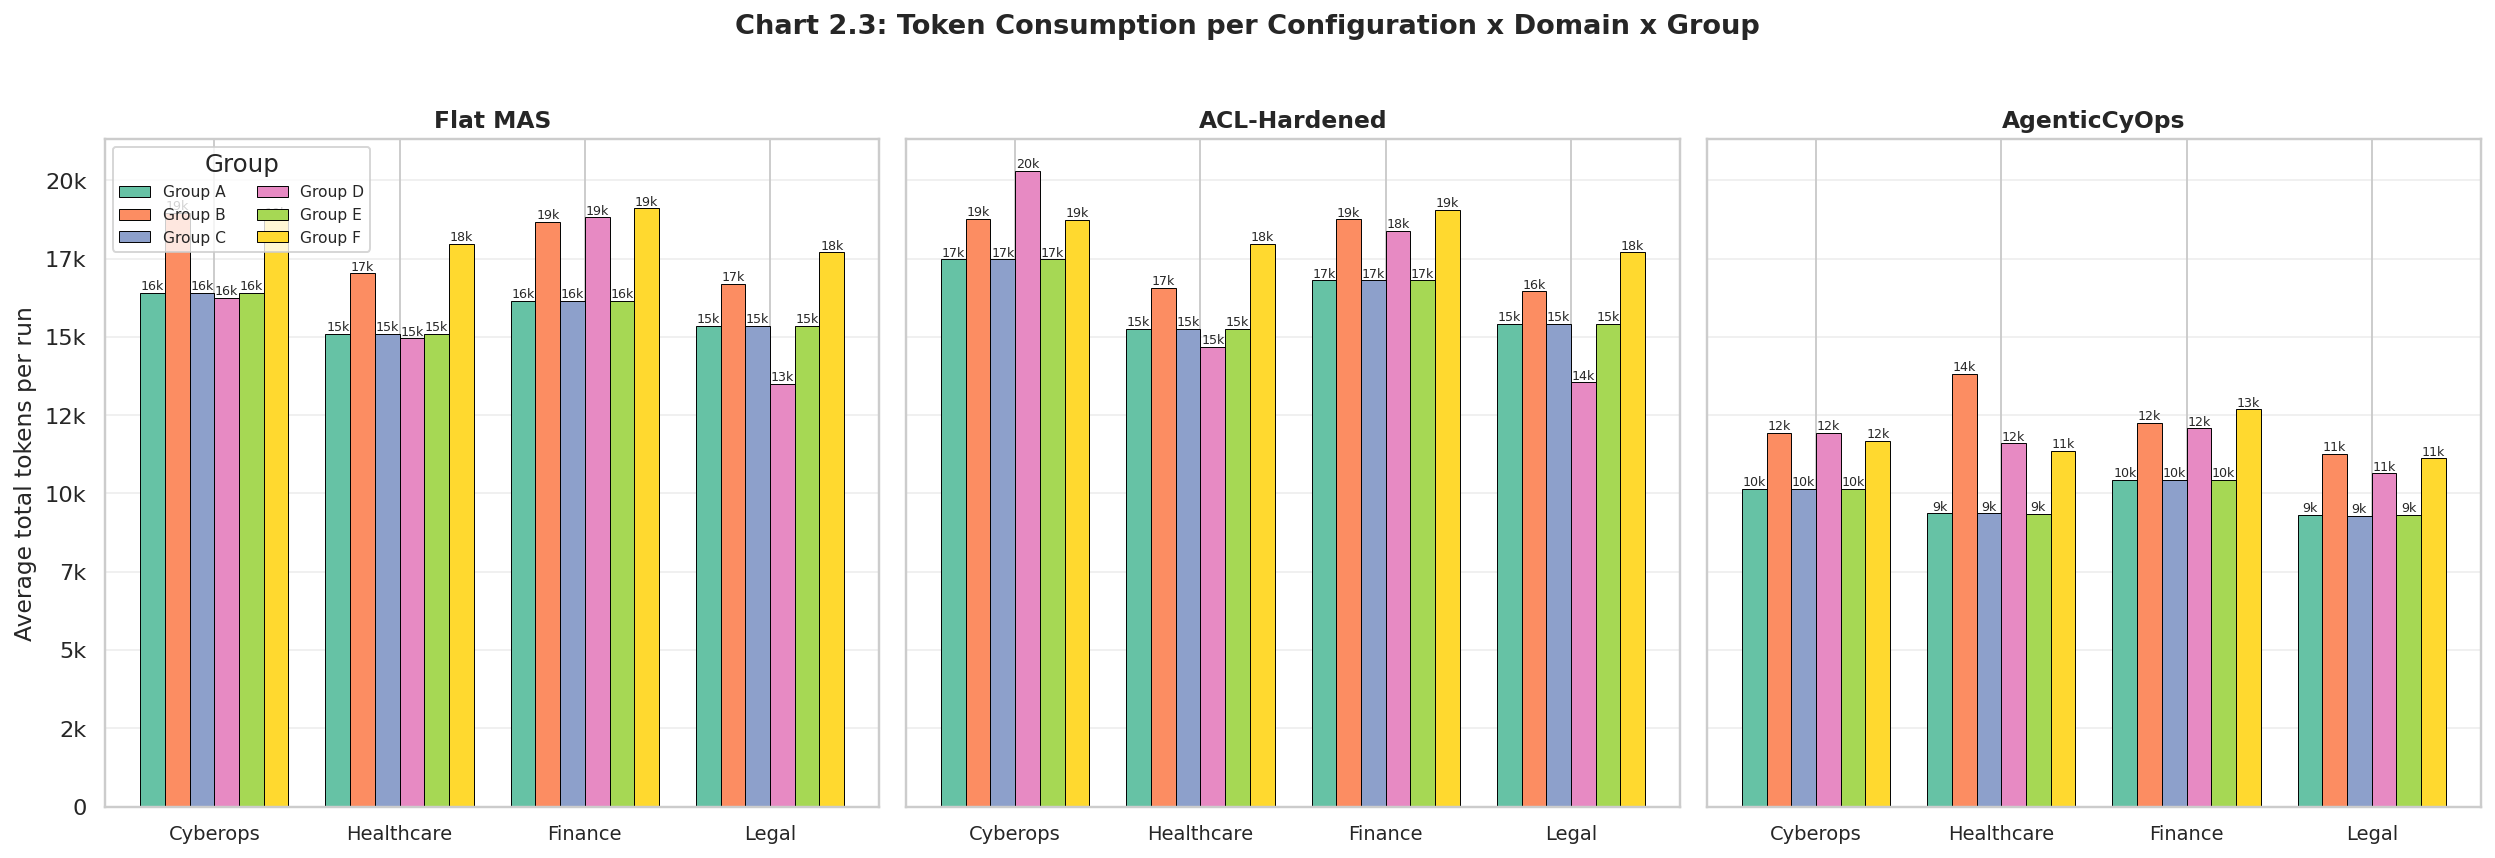


Flat MAS -- domain x group tokens (mean):
group           A      B      C      D      E      F
domain                                              
cyberops    16418  18974  16418  16249  16418  18734
healthcare  15097  17032  15097  14952  15097  17969
finance     16160  18671  16160  18817  16160  19109
legal       15348  16696  15348  13495  15348  17706

ACL-Hardened -- domain x group tokens (mean):
group           A      B      C      D      E      F
domain                                              
cyberops    17479  18780  17479  20307  17479  18734
healthcare  15261  16561  15261  14691  15261  17969
finance     16811  18761  16811  18386  16811  19067
legal       15416  16453  15416  13555  15416  17706

AgenticCyOps -- domain x group tokens (mean):
group           A      B      C      D      E      F
domain                                              
cyberops    10147  11948  10147  11942  10147  11692
healthcare   9363  13831   9363  11604   9343  11365
finance     104

In [7]:
# Chart 2.3: Token consumption per group x domain (all 3 configs)
# One subplot per config; within each, 4 domains x 6 groups.

fig, axes = plt.subplots(1, len(CONFIGS), figsize=(18, 6), sharey=True)
n_groups = len(GROUPS)
n_domains = len(DOMAINS)
width = 0.8 / n_groups
x = np.arange(n_domains)
palette = sns.color_palette('Set2', n_groups)

tok_pivots = {}
for ax, cfg in zip(axes, CONFIGS):
    sub = df[df['config'] == cfg]
    pivot = sub.pivot_table(index='domain', columns='group',
                           values='total_tokens', aggfunc='mean') \
              .reindex(index=DOMAINS, columns=GROUPS)
    tok_pivots[cfg] = pivot

    for i, g in enumerate(GROUPS):
        offset = (i - (n_groups - 1) / 2) * width
        vals = pivot[g].values
        bars = ax.bar(x + offset, vals, width, label=f'Group {g}',
                      color=palette[i], edgecolor='black', linewidth=0.5)
        for b, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(b.get_x() + b.get_width() / 2, v,
                        f'{v/1000:.0f}k', ha='center', va='bottom',
                        fontsize=6.5)

    ax.set_xticks(x)
    ax.set_xticklabels([d.capitalize() for d in DOMAINS], fontsize=10)
    ax.set_title(CONFIG_LABELS[cfg], fontsize=12, fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda v, _: f'{int(v/1000)}k' if v >= 1000 else f'{int(v)}'))
    ax.grid(axis='y', alpha=0.3)

axes[0].set_ylabel('Average total tokens per run')
axes[0].legend(title='Group', loc='upper left', fontsize=8, ncol=2)
fig.suptitle('Chart 2.3: Token Consumption per Configuration x Domain x Group',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print per-config pivots
for cfg in CONFIGS:
    print(f"\n{CONFIG_LABELS[cfg]} -- domain x group tokens (mean):")
    print(tok_pivots[cfg].round(0).astype('Int64'))


## Section 3: Principle Activity Across Configs

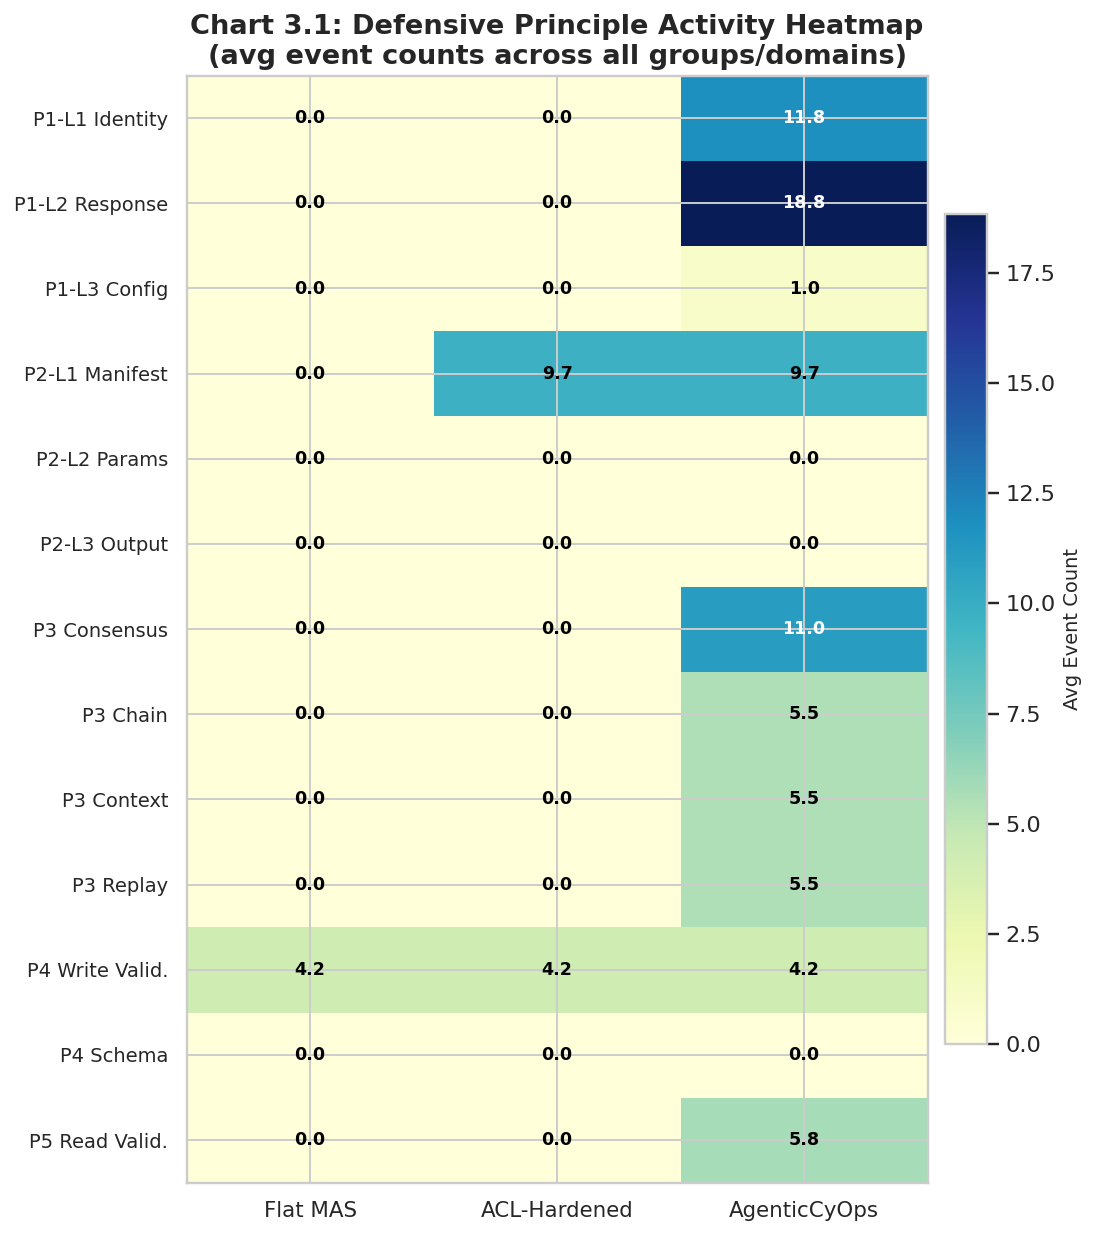

In [8]:
# Chart 3.1: Heatmap — principle layers x configs, values = avg event counts
HEATMAP_ROWS = {
    "P1-L1 Identity":   ["p1_identity_checks"],
    "P1-L2 Response":   ["p1_response_checks"],
    "P1-L3 Config":     ["p1_config_checks"],
    "P2-L1 Manifest":   ["p2_manifest_checks"],
    "P2-L2 Params":     ["p2_parameter_checks"],
    "P2-L3 Output":     ["p2_output_checks"],
    "P3 Consensus":     ["p3_total_validations"],
    "P3 Chain":         ["p3_chain_events"],
    "P3 Context":       ["p3_operational_events"],
    "P3 Replay":        ["p3_replay_events"],
    "P4 Write Valid.":  ["p4_write_validations"],
    "P4 Schema":        ["p4_schema_checks"],
    "P5 Read Valid.":   ["p5_read_validations"],
}

heat_data = np.zeros((len(HEATMAP_ROWS), len(CONFIGS)))
for j, cfg in enumerate(CONFIGS):
    subset = df[df["config"] == cfg]
    for i, (label, cols) in enumerate(HEATMAP_ROWS.items()):
        heat_data[i, j] = subset[cols].sum(axis=1).mean()

fig, ax = plt.subplots(figsize=(8, 9))
im = ax.imshow(heat_data, aspect="auto", cmap="YlGnBu", interpolation="nearest")

ax.set_xticks(range(len(CONFIGS)))
ax.set_xticklabels([CONFIG_LABELS[c] for c in CONFIGS], fontsize=11)
ax.set_yticks(range(len(HEATMAP_ROWS)))
ax.set_yticklabels(list(HEATMAP_ROWS.keys()), fontsize=10)

# Annotate cells
for i in range(heat_data.shape[0]):
    for j in range(heat_data.shape[1]):
        val = heat_data[i, j]
        color = "white" if val > heat_data.max() * 0.55 else "black"
        ax.text(j, i, f"{val:.1f}", ha="center", va="center",
                fontsize=9, fontweight="bold", color=color)

ax.set_title("Chart 3.1: Defensive Principle Activity Heatmap\n(avg event counts across all groups/domains)",
             fontsize=14, fontweight="bold")
cbar = fig.colorbar(im, ax=ax, shrink=0.75, pad=0.02)
cbar.set_label("Avg Event Count", fontsize=10)
plt.tight_layout()
plt.show()

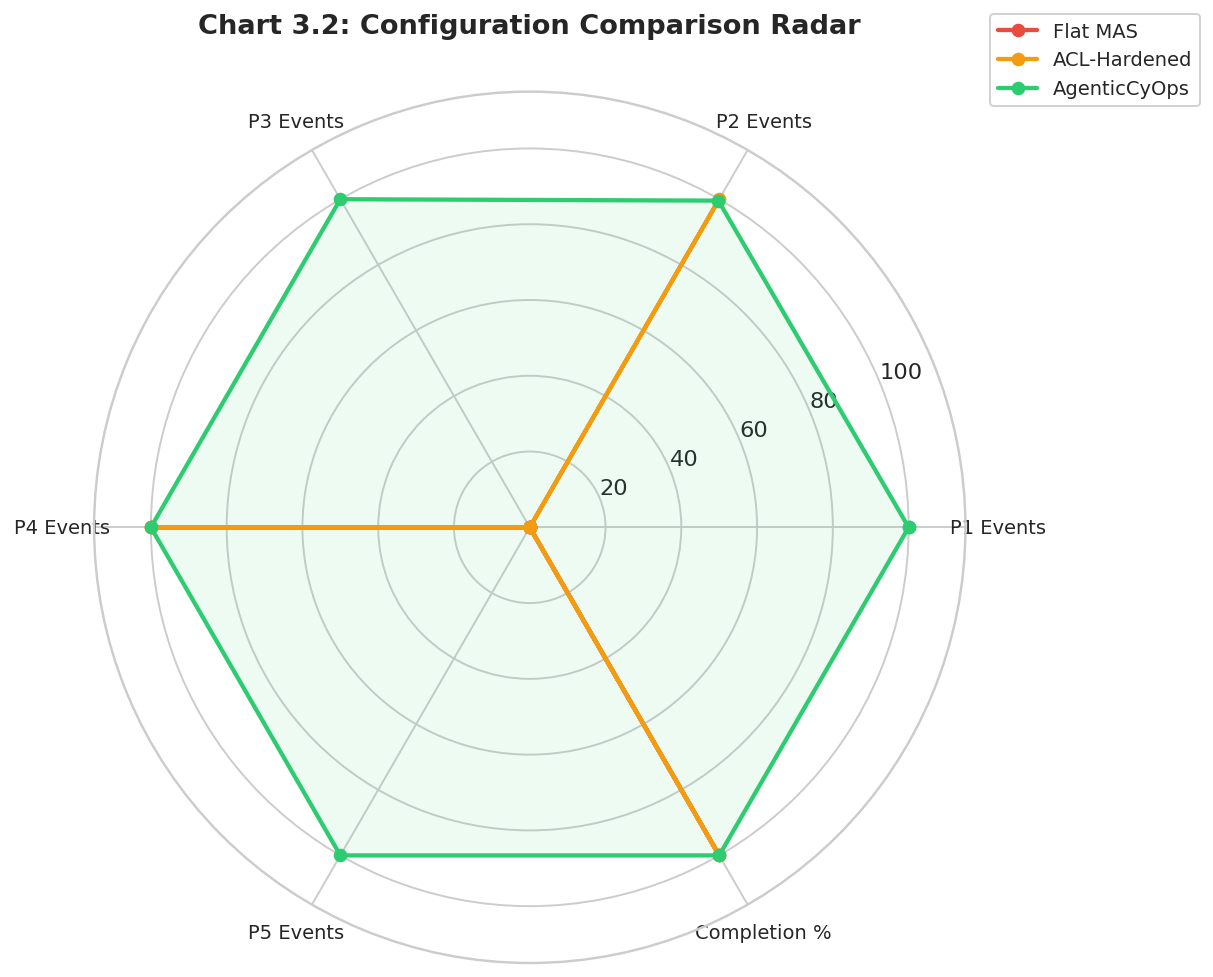

In [9]:
# Chart 3.2: Radar/spider chart — 6 axes x 3 configs
# Axes: P1 events, P2 events, P3 events, P4 events, P5 events, completion rate

def _principle_total(sub, pnum):
    """Sum all mechanism columns for a principle."""
    p_cols = {
        1: ["p1_identity_checks", "p1_response_checks", "p1_config_checks"],
        2: ["p2_manifest_checks", "p2_parameter_checks", "p2_output_checks"],
        3: ["p3_total_validations", "p3_chain_events", "p3_operational_events", "p3_replay_events"],
        4: ["p4_write_validations", "p4_schema_checks", "p4_metadata_checks"],
        5: ["p5_read_validations", "p5_field_filter_events", "p5_query_scope_events", "p5_sanitization_events"],
    }
    existing = [c for c in p_cols[pnum] if c in sub.columns]
    return sub[existing].sum(axis=1).mean() if existing else 0

radar_labels = ["P1 Events", "P2 Events", "P3 Events", "P4 Events", "P5 Events", "Completion %"]
n_axes = len(radar_labels)
angles = np.linspace(0, 2 * np.pi, n_axes, endpoint=False).tolist()
angles += angles[:1]

raw_vals = {}
for cfg in CONFIGS:
    sub = df[df["config"] == cfg]
    vals = [_principle_total(sub, p) for p in range(1, 6)]
    vals.append(sub["phases_completed"].mean() / 4 * 100)
    raw_vals[cfg] = vals

# Normalize to 0-100
max_per_axis = [max(raw_vals[c][i] for c in CONFIGS) for i in range(n_axes)]
max_per_axis = [v if v > 0 else 1 for v in max_per_axis]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
for cfg in CONFIGS:
    normed = [v / m * 100 for v, m in zip(raw_vals[cfg], max_per_axis)]
    normed += normed[:1]
    ax.plot(angles, normed, "o-", linewidth=2.2, label=CONFIG_LABELS[cfg],
            color=CONFIG_COLORS[cfg], markersize=6)
    ax.fill(angles, normed, alpha=0.08, color=CONFIG_COLORS[cfg])

ax.set_thetagrids(np.degrees(angles[:-1]), radar_labels, fontsize=10)
ax.set_ylim(0, 115)
ax.set_title("Chart 3.2: Configuration Comparison Radar",
             fontsize=14, fontweight="bold", pad=30)
ax.legend(loc="upper right", bbox_to_anchor=(1.28, 1.1), frameon=True, framealpha=0.9)
plt.tight_layout()
plt.show()

## Section 4: Attack Surface Reduction

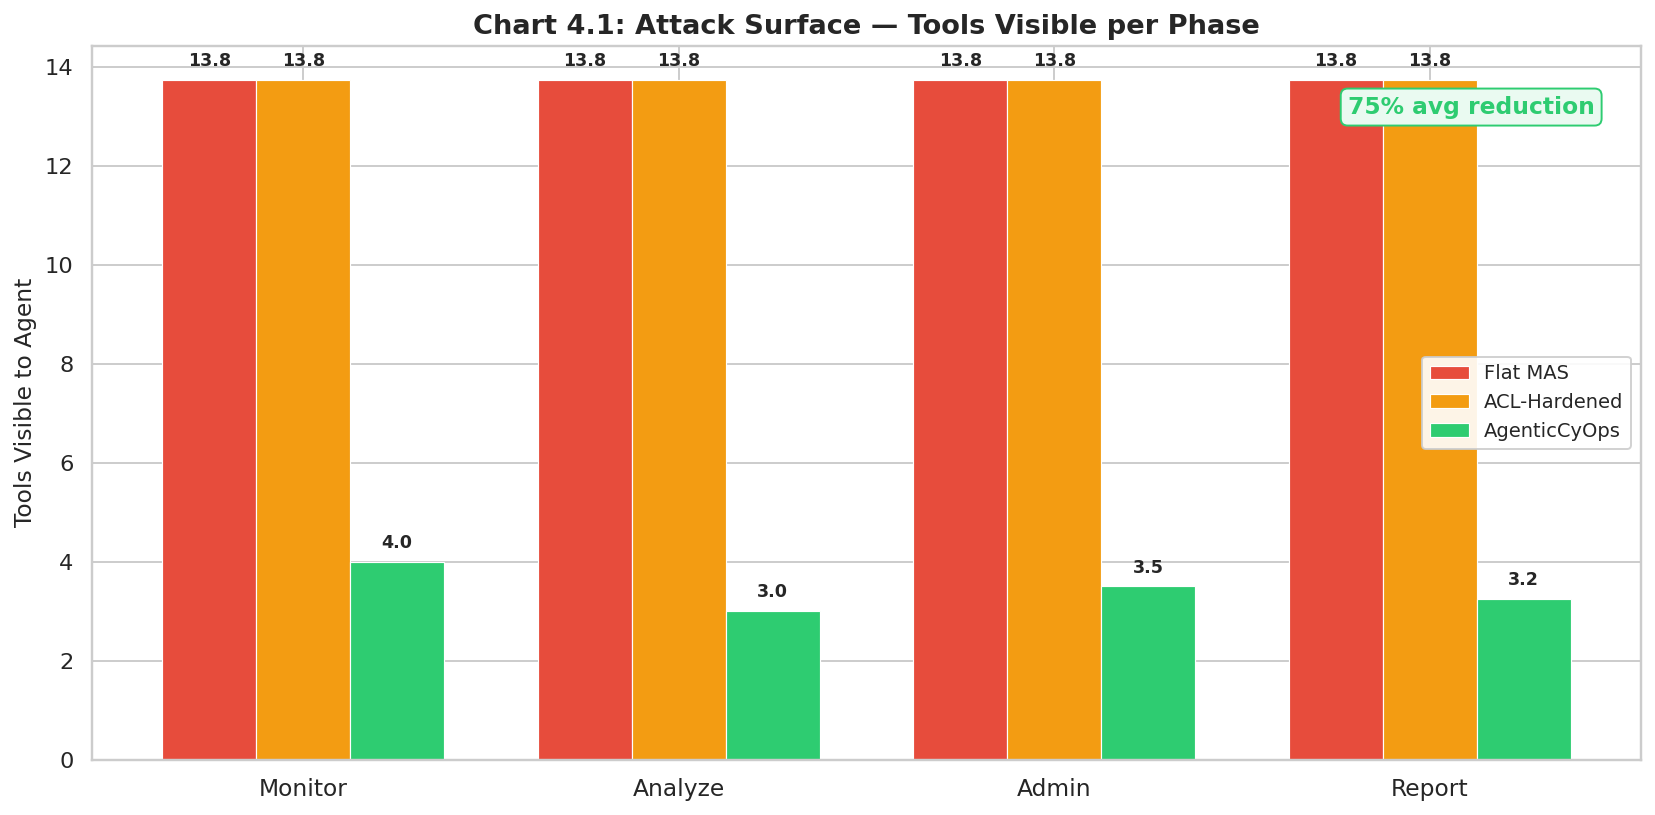

In [10]:
# Chart 4.1: Grouped bar — Tools visible per phase per config (averaged across domains)
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(PHASES))
w = 0.25

for i, cfg in enumerate(CONFIGS):
    vals = []
    for phase in PHASES:
        if cfg == "agenticcyops":
            # Average manifest tools across domains for this phase
            vals.append(np.mean([TOOL_MANIFEST[d].get(phase, 0) for d in DOMAINS]))
        else:
            # Flat/ACL see ALL tools for the domain (average across domains)
            vals.append(np.mean([TOOL_MANIFEST[d]["total"] for d in DOMAINS]))
    bars = ax.bar(x + i * w, vals, w, label=CONFIG_LABELS[cfg],
                  color=CONFIG_COLORS[cfg], edgecolor="white", linewidth=0.6)
    _bar_labels(ax, bars, fmt="{:.1f}", offset=0.2)

ax.set_xticks(x + w)
ax.set_xticklabels([p.title() for p in PHASES], fontsize=12)
ax.set_ylabel("Tools Visible to Agent")
ax.set_title("Chart 4.1: Attack Surface — Tools Visible per Phase",
             fontsize=14, fontweight="bold")
ax.legend(frameon=True, framealpha=0.9)

# Annotation: average reduction
avg_flat = np.mean([TOOL_MANIFEST[d]["total"] for d in DOMAINS])
avg_aco = np.mean([np.mean([TOOL_MANIFEST[d].get(p, 0) for d in DOMAINS]) for p in PHASES])
reduction_pct = (1 - avg_aco / avg_flat) * 100
ax.text(0.97, 0.93, f"{reduction_pct:.0f}% avg reduction",
        transform=ax.transAxes, ha="right", va="top", fontsize=12,
        color=CONFIG_COLORS["agenticcyops"], fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#eafaf1",
                  edgecolor=CONFIG_COLORS["agenticcyops"]))

plt.tight_layout()
plt.show()

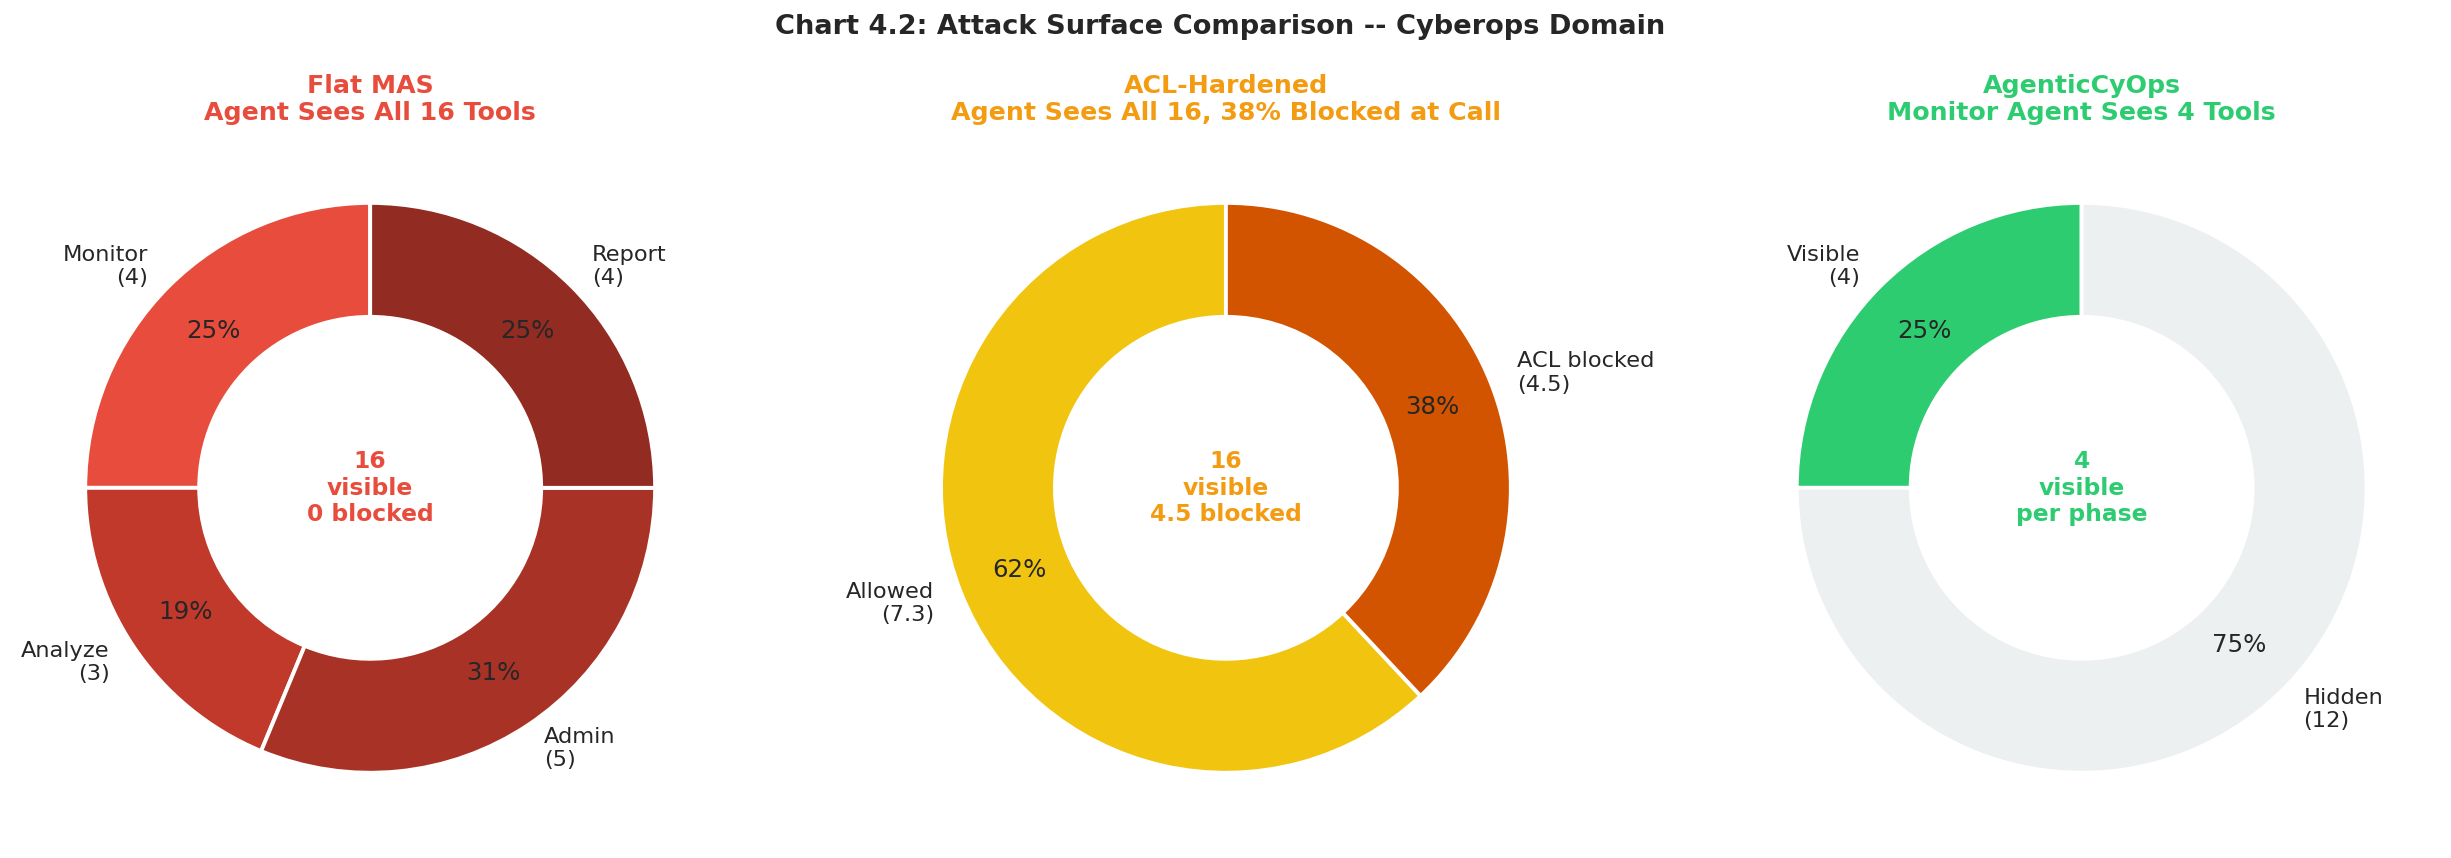


ACL-Hardened (cyberops): 7.3 allowed / 4.5 blocked per run (block rate 38%)
AgenticCyOps (cyberops): monitor agent sees 4/16 tools = 25% of surface


In [11]:
# Chart 4.2: Donut triple — attack surface per config (cyberops showcase)
# Flat: sees all 16 tools, 0 blocked.  ACL-Hardened: sees all 16 but ACL-layer
# denies ~47% at call time.  AgenticCyOps: monitor agent sees only manifest tools.

domain_ex = "cyberops"
total_flat = TOOL_MANIFEST[domain_ex]["total"]
manifest_monitor = TOOL_MANIFEST[domain_ex]["monitor"]

# Average ACL deny rate for cyberops from the real baseline logs
acl_sub = df[(df["domain"] == domain_ex) & (df["config"] == "acl_hardened")]
acl_allowed = acl_sub["tool_calls_allowed"].mean()
acl_denied = acl_sub["tool_calls_denied"].mean()
acl_total = acl_allowed + acl_denied if (acl_allowed + acl_denied) > 0 else 1
acl_visible = total_flat  # ACL sees all tools, blocks at network layer

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# --- Left donut: Flat agent (all 16 tools visible, none blocked) ---
phase_vals_flat = [TOOL_MANIFEST[domain_ex][p] for p in PHASES]
phase_labels_flat = [f"{p.title()}\n({v})" for p, v in zip(PHASES, phase_vals_flat)]
colors_flat = ["#e74c3c", "#c0392b", "#a93226", "#922b21"]
ax1.pie(phase_vals_flat, labels=phase_labels_flat, autopct="%1.0f%%",
        colors=colors_flat, startangle=90, pctdistance=0.78,
        wedgeprops=dict(width=0.4, edgecolor="white", linewidth=2))
ax1.set_title(f"Flat MAS\nAgent Sees All {total_flat} Tools",
              fontsize=13, fontweight="bold", color=CONFIG_COLORS["flat"])
ax1.add_artist(plt.Circle((0, 0), 0.55, fc="white"))
ax1.text(0, 0, f"{total_flat}\nvisible\n0 blocked",
         ha="center", va="center", fontsize=12, fontweight="bold",
         color=CONFIG_COLORS["flat"])

# --- Middle donut: ACL-Hardened (sees all, blocks at call time) ---
# Visualise allowed vs ACL-blocked at the tool-call layer
acl_blocked_pct = acl_denied / acl_total * 100 if acl_total else 0
sizes_acl = [acl_allowed, acl_denied]
labels_acl = [f"Allowed\n({acl_allowed:.1f})", f"ACL blocked\n({acl_denied:.1f})"]
colors_acl = ["#f1c40f", "#d35400"]
ax2.pie(sizes_acl, labels=labels_acl, autopct="%1.0f%%",
        colors=colors_acl, startangle=90, pctdistance=0.78,
        wedgeprops=dict(width=0.4, edgecolor="white", linewidth=2))
ax2.set_title(f"ACL-Hardened\nAgent Sees All {acl_visible}, {acl_blocked_pct:.0f}% Blocked at Call",
              fontsize=13, fontweight="bold", color=CONFIG_COLORS["acl_hardened"])
ax2.add_artist(plt.Circle((0, 0), 0.55, fc="white"))
ax2.text(0, 0, f"{acl_visible}\nvisible\n{acl_denied:.1f} blocked",
         ha="center", va="center", fontsize=12, fontweight="bold",
         color=CONFIG_COLORS["acl_hardened"])

# --- Right donut: AgenticCyOps monitor agent (only manifest tools) ---
other_phases = total_flat - manifest_monitor
sizes_aco = [manifest_monitor, other_phases]
labels_aco = [f"Visible\n({manifest_monitor})", f"Hidden\n({other_phases})"]
colors_aco = ["#2ecc71", "#ecf0f1"]
ax3.pie(sizes_aco, labels=labels_aco, autopct="%1.0f%%",
        colors=colors_aco, startangle=90, pctdistance=0.78,
        wedgeprops=dict(width=0.4, edgecolor="white", linewidth=2))
ax3.set_title(f"AgenticCyOps\nMonitor Agent Sees {manifest_monitor} Tools",
              fontsize=13, fontweight="bold", color=CONFIG_COLORS["agenticcyops"])
ax3.add_artist(plt.Circle((0, 0), 0.55, fc="white"))
ax3.text(0, 0, f"{manifest_monitor}\nvisible\nper phase",
         ha="center", va="center", fontsize=12, fontweight="bold",
         color=CONFIG_COLORS["agenticcyops"])

fig.suptitle(f"Chart 4.2: Attack Surface Comparison -- {domain_ex.capitalize()} Domain",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"\nACL-Hardened ({domain_ex}): {acl_allowed:.1f} allowed / {acl_denied:.1f} blocked per run "
      f"(block rate {acl_blocked_pct:.0f}%)")
print(f"AgenticCyOps ({domain_ex}): monitor agent sees {manifest_monitor}/{total_flat} tools "
      f"= {manifest_monitor/total_flat:.0%} of surface")


## Section 5: False Positive Analysis

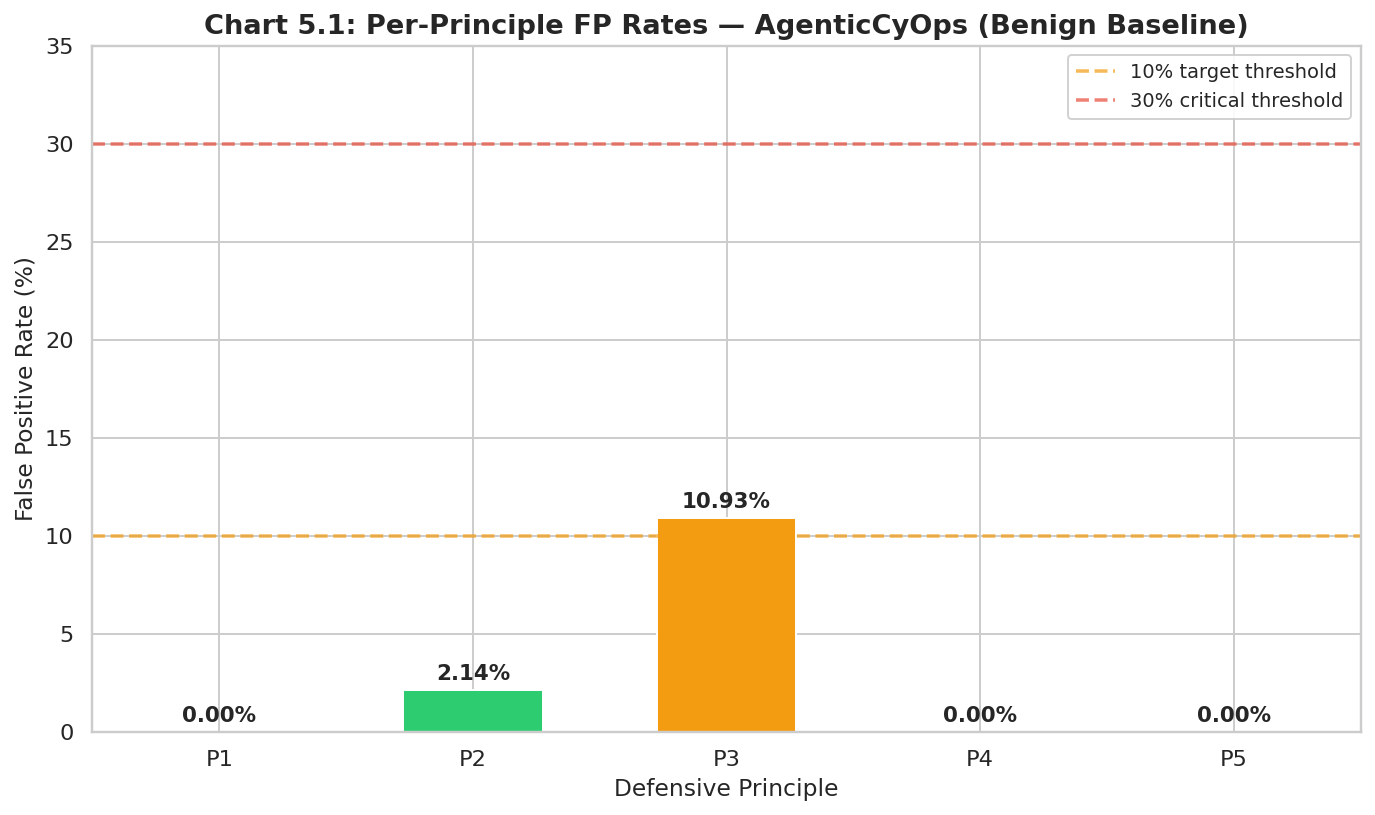

In [12]:
# Chart 5.1: Per-principle FP rate bar chart for agenticcyops with threshold lines
aco = df[df["config"] == "agenticcyops"]
principles = ["P1", "P2", "P3", "P4", "P5"]
fp_means = [aco[f"p{i}_fp_rate"].mean() * 100 for i in range(1, 6)]

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#e74c3c" if r > 30 else "#f39c12" if r > 10 else "#2ecc71" for r in fp_means]
bars = ax.bar(principles, fp_means, color=colors, edgecolor="white", linewidth=1, width=0.55)

# Threshold lines
ax.axhline(y=10, color="#f39c12", linestyle="--", linewidth=1.8, alpha=0.7, label="10% target threshold")
ax.axhline(y=30, color="#e74c3c", linestyle="--", linewidth=1.8, alpha=0.7, label="30% critical threshold")

for bar, r in zip(bars, fp_means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"{r:.2f}%", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_xlabel("Defensive Principle", fontsize=12)
ax.set_ylabel("False Positive Rate (%)", fontsize=12)
ax.set_title("Chart 5.1: Per-Principle FP Rates — AgenticCyOps (Benign Baseline)",
             fontsize=14, fontweight="bold")
ax.legend(loc="upper right", frameon=True, framealpha=0.9, fontsize=10)
ax.set_ylim(0, max(max(fp_means) * 1.4, 35))
plt.tight_layout()
plt.show()

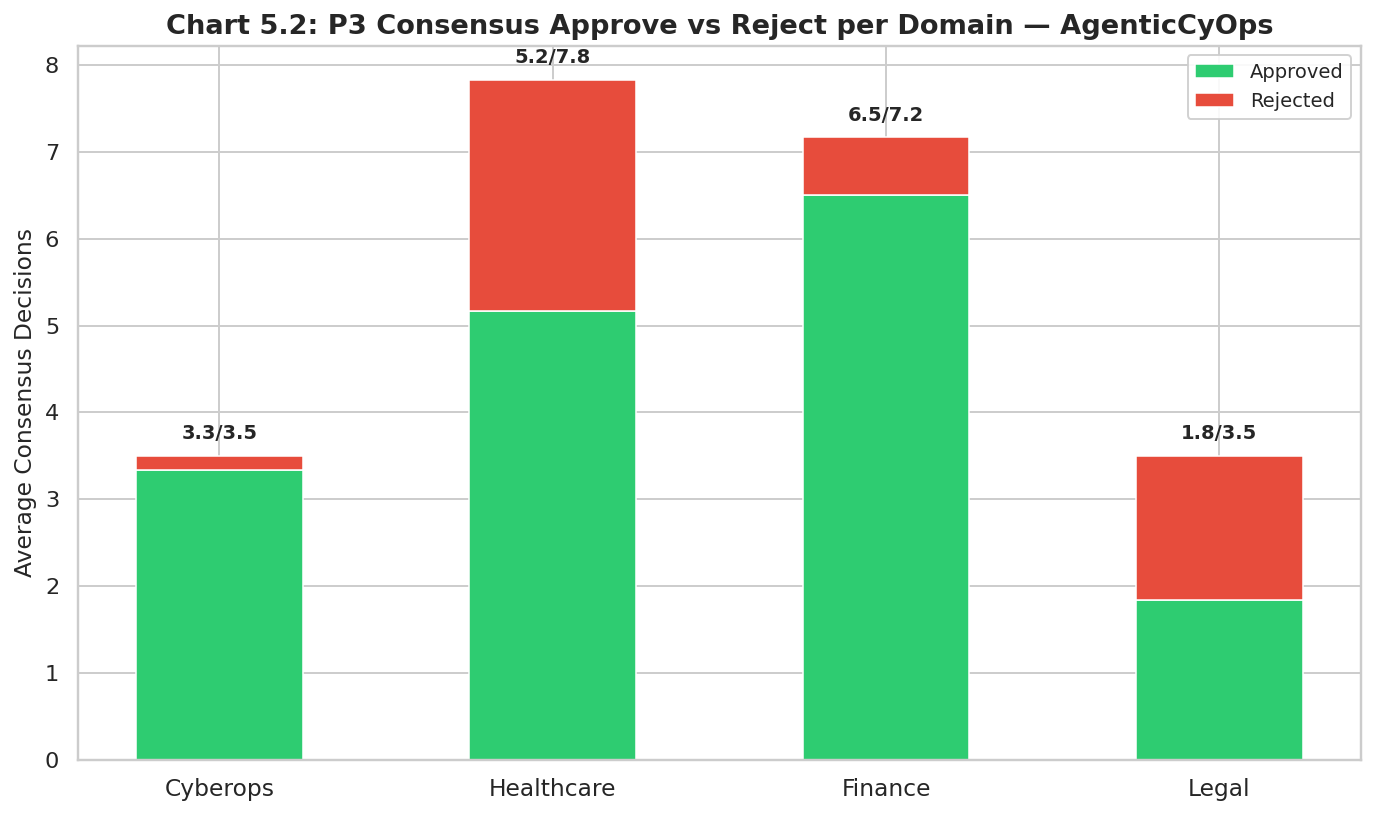

In [13]:
# Chart 5.2: Consensus rejection analysis — stacked bar per domain (agenticcyops)
aco = df[df["config"] == "agenticcyops"]
cons_agg = aco.groupby("domain")[["p3_approved", "p3_rejected"]].mean().reindex(DOMAINS)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(DOMAINS))
w = 0.5

bars_a = ax.bar(x, cons_agg["p3_approved"], w, label="Approved", color="#2ecc71",
                edgecolor="white", linewidth=0.8)
bars_r = ax.bar(x, cons_agg["p3_rejected"], w, bottom=cons_agg["p3_approved"],
                label="Rejected", color="#e74c3c", edgecolor="white", linewidth=0.8)

# Labels
for i in range(len(DOMAINS)):
    total = cons_agg["p3_approved"].iloc[i] + cons_agg["p3_rejected"].iloc[i]
    if total > 0:
        ax.text(x[i], total + 0.15, f"{cons_agg['p3_approved'].iloc[i]:.1f}/{total:.1f}",
                ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels([d.title() for d in DOMAINS], fontsize=12)
ax.set_ylabel("Average Consensus Decisions")
ax.set_title("Chart 5.2: P3 Consensus Approve vs Reject per Domain — AgenticCyOps",
             fontsize=14, fontweight="bold")
ax.legend(frameon=True, framealpha=0.9)
plt.tight_layout()
plt.show()

In [14]:
# Table 5.1: FP rates per domain per group for agenticcyops
aco = df[df["config"] == "agenticcyops"].copy()
aco["total_fp_pct"] = aco["total_fp_rate"] * 100

fp_pivot = aco.pivot_table(
    index="group", columns="domain", values="total_fp_pct", aggfunc="mean"
).reindex(index=GROUPS, columns=DOMAINS)
fp_pivot.columns = [d.title() for d in DOMAINS]

# Add row mean
fp_pivot["Mean"] = fp_pivot.mean(axis=1)
# Add column mean
fp_pivot.loc["Mean"] = fp_pivot.mean(axis=0)

print("Table 5.1: Total FP Rate (%) per Group x Domain — AgenticCyOps")
print("=" * 65)
display(fp_pivot.round(2).style.format("{:.2f}%").background_gradient(cmap="RdYlGn_r", vmin=0, vmax=30))

Table 5.1: Total FP Rate (%) per Group x Domain — AgenticCyOps


,Cyberops,Healthcare,Finance,Legal,Mean
group,,,,,
A,0.00%,14.29%,8.33%,25.00%,11.90%
B,0.00%,30.00%,22.22%,10.00%,15.56%
C,0.00%,7.14%,0.00%,8.33%,3.87%
D,37.50%,31.58%,10.00%,22.22%,25.32%
E,0.00%,21.43%,8.33%,25.00%,13.69%
F,0.00%,22.22%,10.00%,0.00%,8.06%
Mean,6.25%,21.11%,9.81%,15.09%,13.07%


## Section 6: Latency & Token Overhead

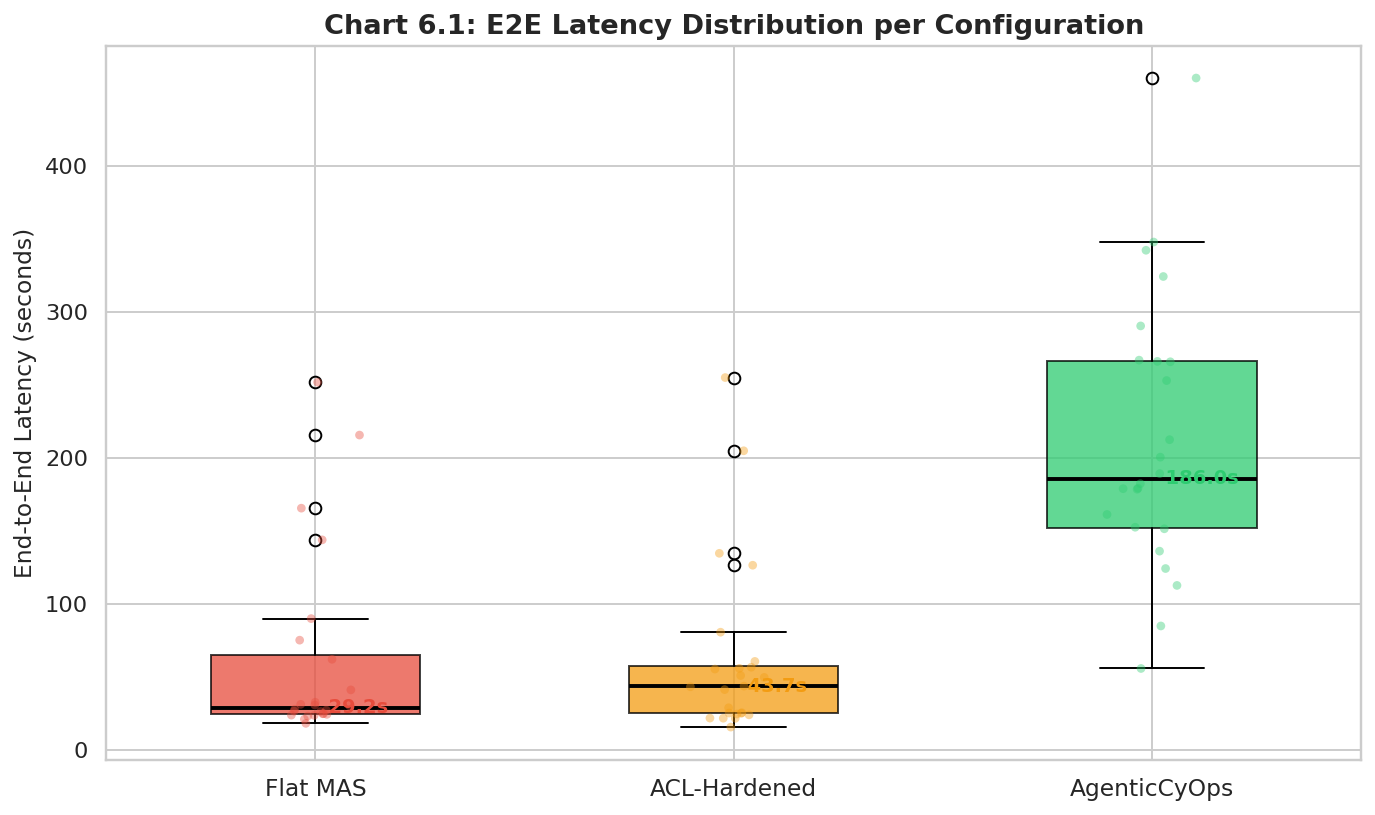

In [15]:
# Chart 6.1: Box plot — E2E latency per config across all groups/domains
fig, ax = plt.subplots(figsize=(10, 6))

box_data = [df[df["config"] == cfg]["e2e_latency_s"].dropna().values for cfg in CONFIGS]
bp = ax.boxplot(box_data, patch_artist=True, widths=0.5,
                medianprops=dict(color="black", linewidth=2))

for patch, cfg in zip(bp["boxes"], CONFIGS):
    patch.set_facecolor(CONFIG_COLORS[cfg])
    patch.set_alpha(0.75)
    patch.set_edgecolor("black")

# Overlay individual points
for i, cfg in enumerate(CONFIGS):
    vals = df[df["config"] == cfg]["e2e_latency_s"].dropna().values
    jitter = np.random.normal(0, 0.04, len(vals))
    ax.scatter(np.full_like(vals, i + 1) + jitter, vals,
               alpha=0.4, s=20, color=CONFIG_COLORS[cfg], zorder=3, edgecolor="none")

ax.set_xticklabels([CONFIG_LABELS[c] for c in CONFIGS], fontsize=12)
ax.set_ylabel("End-to-End Latency (seconds)")
ax.set_title("Chart 6.1: E2E Latency Distribution per Configuration",
             fontsize=14, fontweight="bold")

# Annotate medians
for i, cfg in enumerate(CONFIGS):
    med = df[df["config"] == cfg]["e2e_latency_s"].median()
    ax.text(i + 1, med, f"  {med:.1f}s", va="center", ha="left",
            fontsize=10, fontweight="bold", color=CONFIG_COLORS[cfg])

plt.tight_layout()
plt.show()

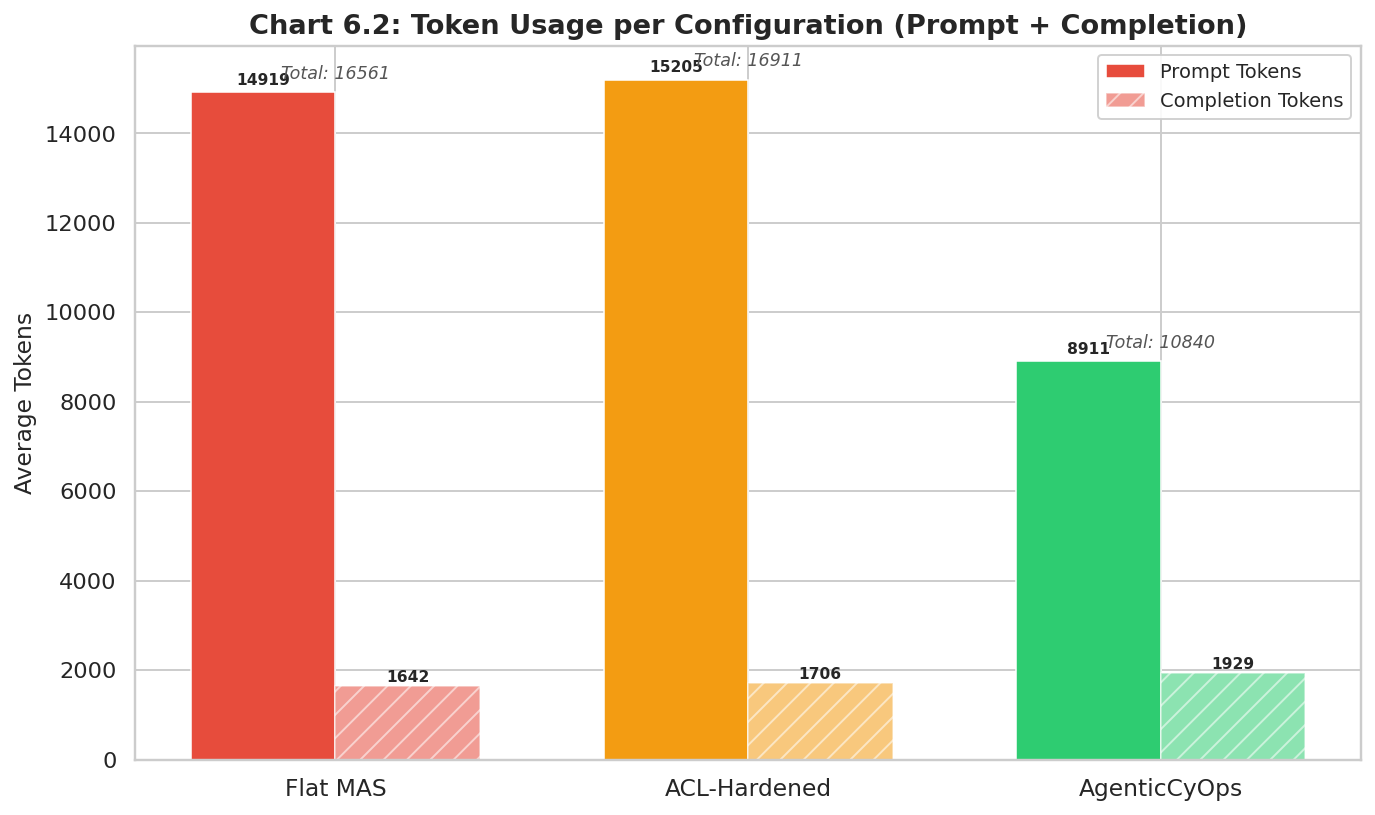

In [16]:
# Chart 6.2: Grouped bar — Token usage (prompt + completion) per config
token_agg = df.groupby("config")[["tokens_prompt", "tokens_completion"]].mean().reindex(CONFIGS)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(CONFIGS))
w = 0.35

bars_p = ax.bar(x - w/2, token_agg["tokens_prompt"], w, label="Prompt Tokens",
                color=[CONFIG_COLORS[c] for c in CONFIGS], edgecolor="white", linewidth=0.8)
bars_c = ax.bar(x + w/2, token_agg["tokens_completion"], w, label="Completion Tokens",
                color=[CONFIG_COLORS[c] for c in CONFIGS], edgecolor="white", linewidth=0.8,
                alpha=0.55, hatch="//")

_bar_labels(ax, bars_p, fmt="{:.0f}", fontsize=8, offset=100)
_bar_labels(ax, bars_c, fmt="{:.0f}", fontsize=8, offset=30)

ax.set_xticks(x)
ax.set_xticklabels([CONFIG_LABELS[c] for c in CONFIGS], fontsize=12)
ax.set_ylabel("Average Tokens")
ax.set_title("Chart 6.2: Token Usage per Configuration (Prompt + Completion)",
             fontsize=14, fontweight="bold")
ax.legend(frameon=True, framealpha=0.9)

# Annotate total
for i, cfg in enumerate(CONFIGS):
    total = token_agg.loc[cfg].sum()
    ax.text(x[i], token_agg.loc[cfg, "tokens_prompt"] + 300,
            f"Total: {total:.0f}", ha="center", fontsize=9, fontstyle="italic", color="#555")

plt.tight_layout()
plt.show()

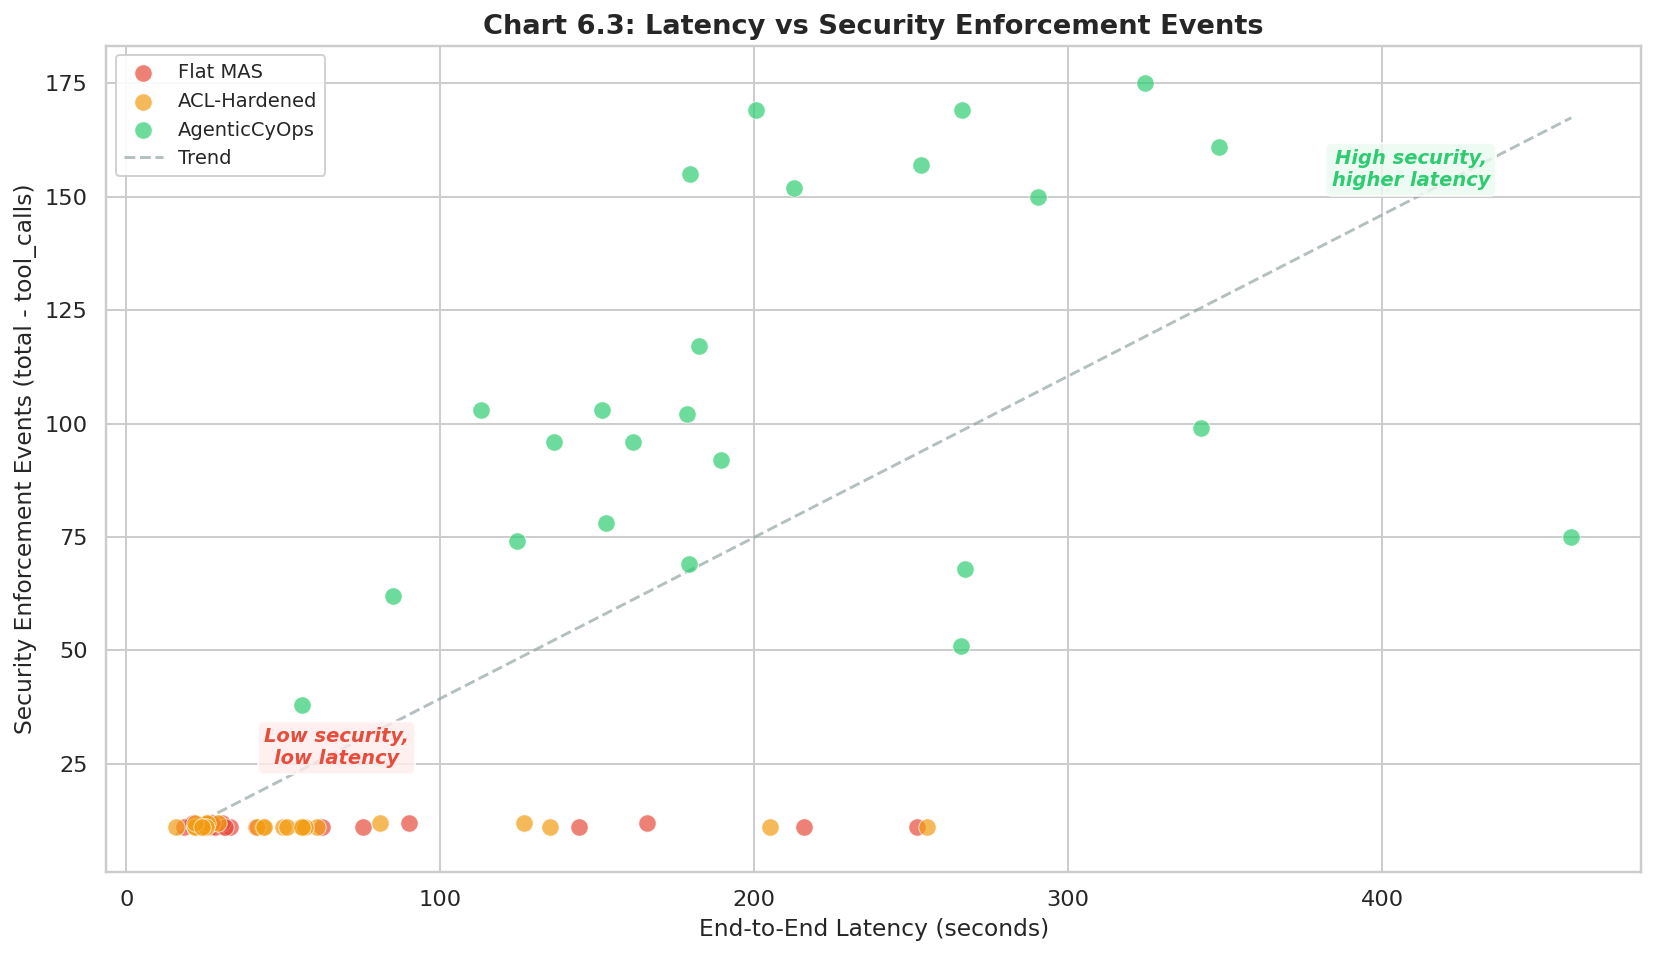

In [17]:
# Chart 6.3: Scatter — Latency vs total security events
# Shows that more enforcement = more latency but better security coverage
fig, ax = plt.subplots(figsize=(12, 7))

for cfg in CONFIGS:
    sub = df[df["config"] == cfg]
    # Security events = total_events - tool_calls_total (enforcement overhead)
    security_events = sub["total_events"] - sub["tool_calls_total"]
    ax.scatter(sub["e2e_latency_s"], security_events,
               color=CONFIG_COLORS[cfg], label=CONFIG_LABELS[cfg],
               s=80, alpha=0.7, edgecolors="white", linewidth=0.5, zorder=3)

# Trend line across all points
all_latency = df["e2e_latency_s"].values
all_security = (df["total_events"] - df["tool_calls_total"]).values
mask = np.isfinite(all_latency) & np.isfinite(all_security)
if mask.sum() > 2:
    z = np.polyfit(all_latency[mask], all_security[mask], 1)
    p = np.poly1d(z)
    x_line = np.linspace(all_latency[mask].min(), all_latency[mask].max(), 100)
    ax.plot(x_line, p(x_line), "--", color="#95a5a6", linewidth=1.5, alpha=0.7, label="Trend")

ax.set_xlabel("End-to-End Latency (seconds)", fontsize=12)
ax.set_ylabel("Security Enforcement Events (total - tool_calls)", fontsize=12)
ax.set_title("Chart 6.3: Latency vs Security Enforcement Events",
             fontsize=14, fontweight="bold")
ax.legend(frameon=True, framealpha=0.9, fontsize=10)

# Annotate regions
ax.annotate("High security,\nhigher latency", xy=(0.85, 0.85), xycoords="axes fraction",
            fontsize=10, fontstyle="italic", color="#2ecc71", fontweight="bold",
            ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="#eafaf1", alpha=0.8))
ax.annotate("Low security,\nlow latency", xy=(0.15, 0.15), xycoords="axes fraction",
            fontsize=10, fontstyle="italic", color="#e74c3c", fontweight="bold",
            ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="#fdedec", alpha=0.8))

plt.tight_layout()
plt.show()

## Section 7: Cross-Domain Consistency

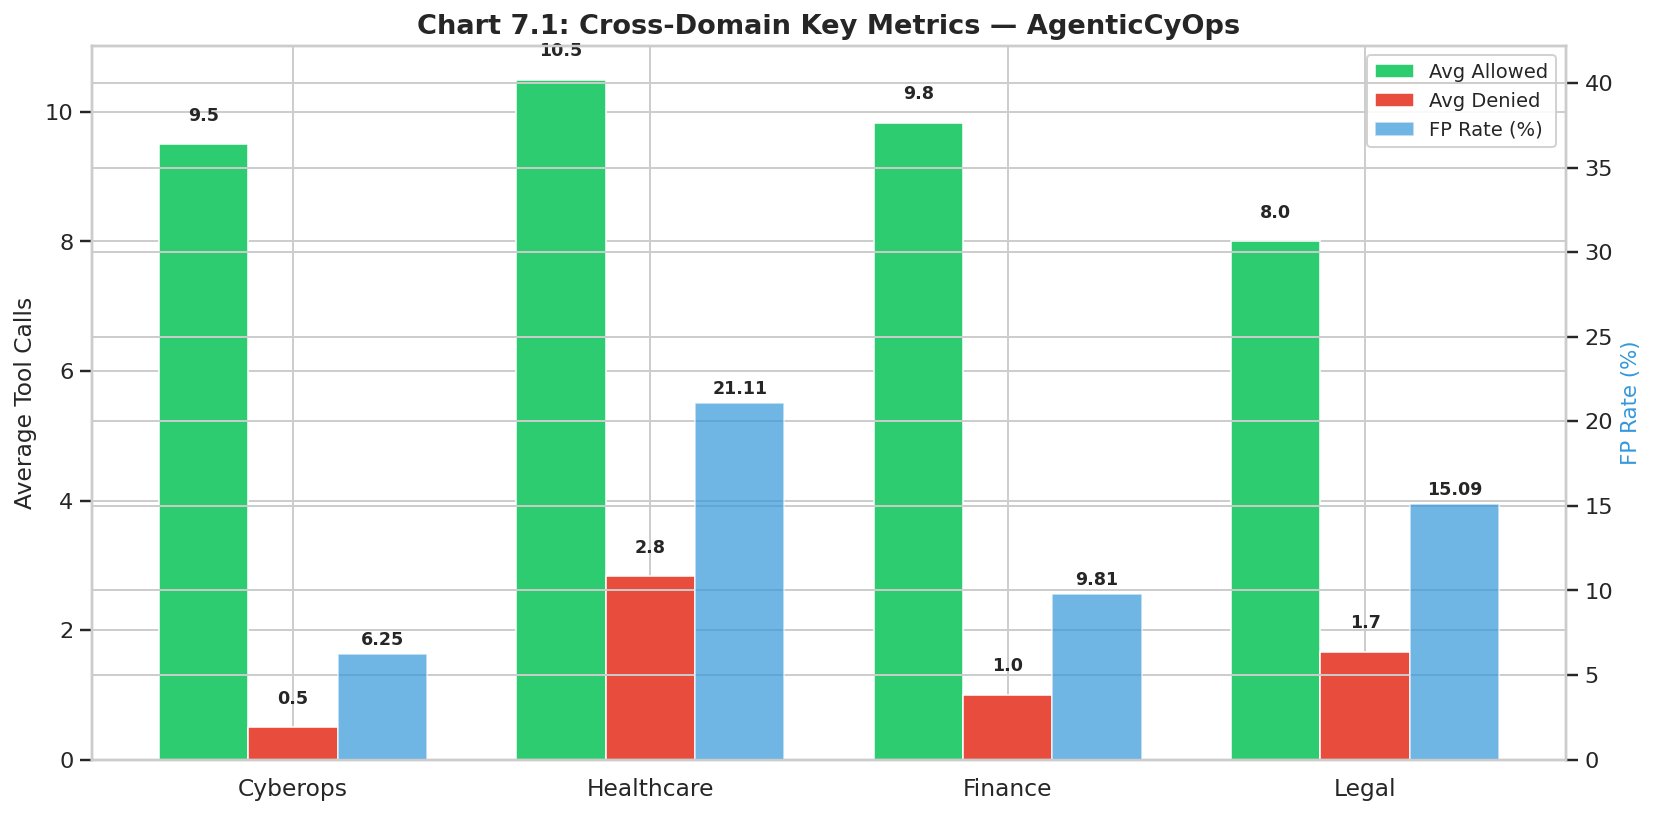

In [18]:
# Chart 7.1: Grouped bar — Key metrics per domain for agenticcyops
aco = df[df["config"] == "agenticcyops"]
dom_agg = aco.groupby("domain").agg(
    allowed=("tool_calls_allowed", "mean"),
    denied=("tool_calls_denied", "mean"),
    fp_rate=("total_fp_rate", lambda s: s.mean() * 100),
).reindex(DOMAINS)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(DOMAINS))
w = 0.25

bars1 = ax.bar(x - w, dom_agg["allowed"], w, label="Avg Allowed", color="#2ecc71",
               edgecolor="white", linewidth=0.8)
bars2 = ax.bar(x, dom_agg["denied"], w, label="Avg Denied", color="#e74c3c",
               edgecolor="white", linewidth=0.8)

# FP rate on secondary axis
ax2 = ax.twinx()
bars3 = ax2.bar(x + w, dom_agg["fp_rate"], w, label="FP Rate (%)", color="#3498db",
                edgecolor="white", linewidth=0.8, alpha=0.7)
ax2.set_ylabel("FP Rate (%)", fontsize=11, color="#3498db")
ax2.set_ylim(0, max(dom_agg["fp_rate"].max() * 2, 20))

_bar_labels(ax, bars1, fmt="{:.1f}")
_bar_labels(ax, bars2, fmt="{:.1f}")
_bar_labels(ax2, bars3, fmt="{:.2f}")

ax.set_xticks(x)
ax.set_xticklabels([d.title() for d in DOMAINS], fontsize=12)
ax.set_ylabel("Average Tool Calls")
ax.set_title("Chart 7.1: Cross-Domain Key Metrics — AgenticCyOps",
             fontsize=14, fontweight="bold")

# Combined legend
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right", frameon=True, framealpha=0.9)

plt.tight_layout()
plt.show()

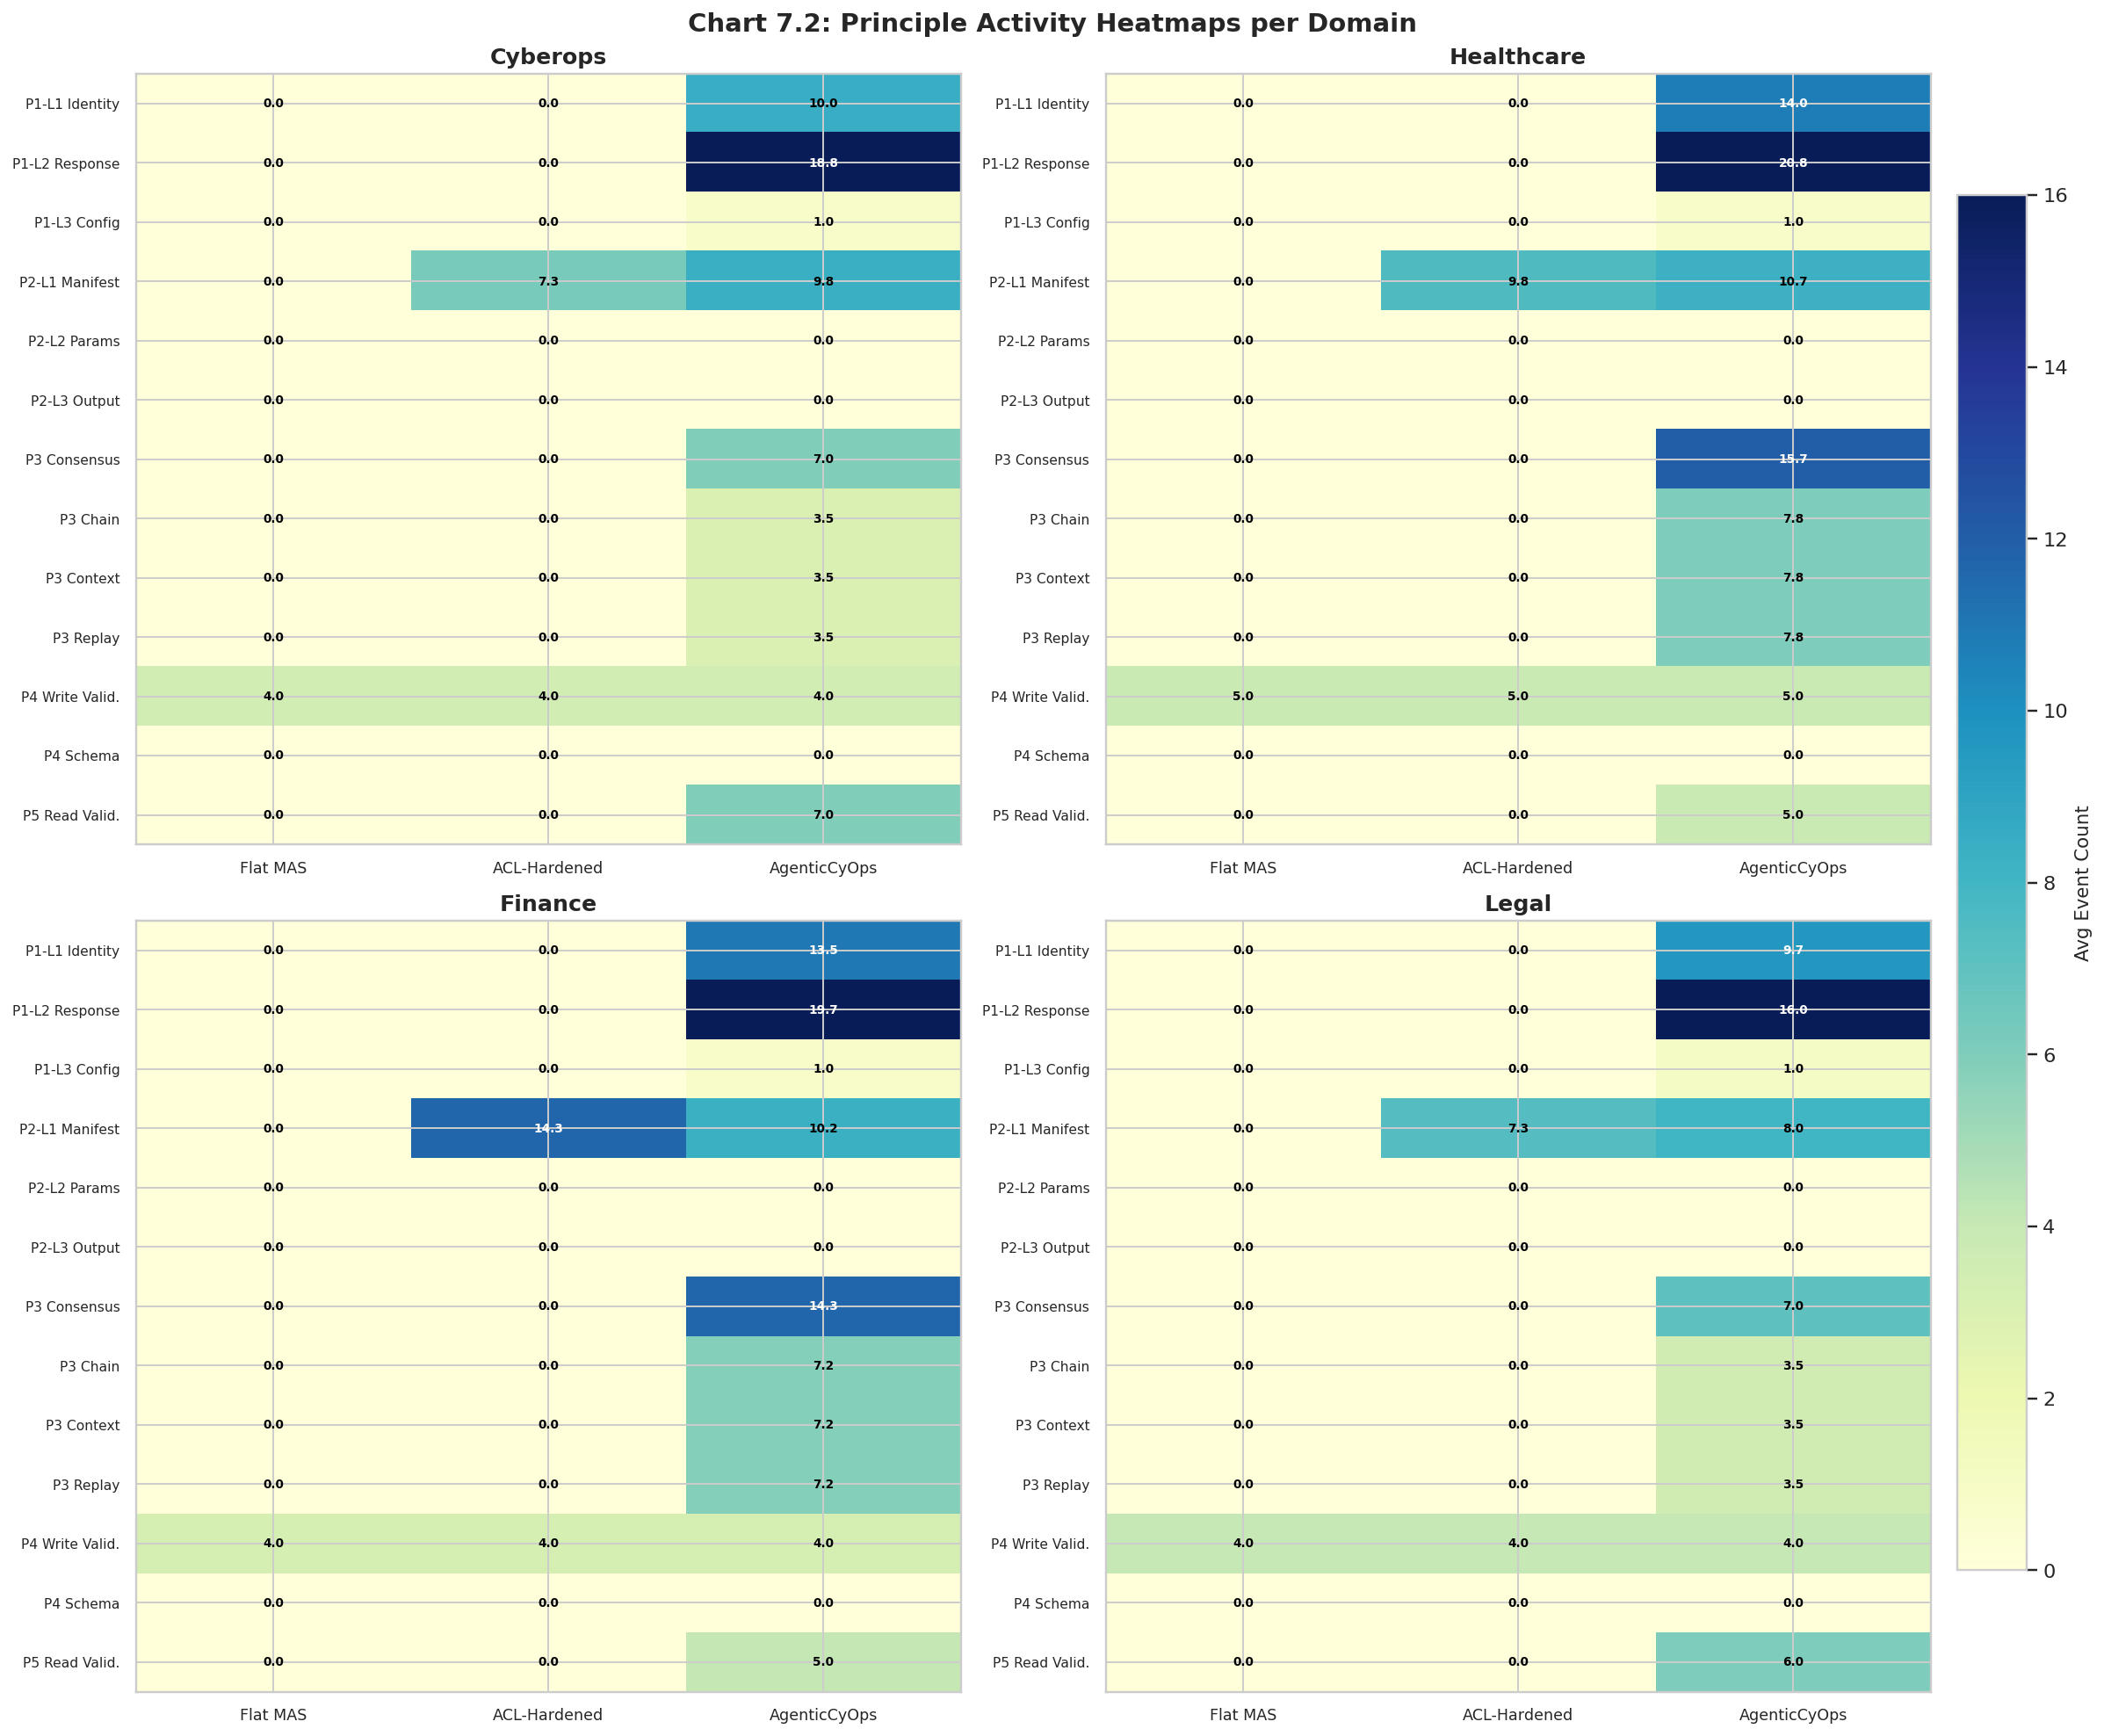

In [19]:
# Chart 7.2: Small multiples — 4 panels (one per domain) showing principle activity heatmaps
# Each panel: principle layers (rows) x configs (columns) for agenticcyops only average across groups

fig, axes = plt.subplots(2, 2, figsize=(17, 14), constrained_layout=True)
axes_flat = axes.flatten()

last_im = None
for idx, domain in enumerate(DOMAINS):
    ax = axes_flat[idx]
    dom_df = df[df["domain"] == domain]

    heat = np.zeros((len(HEATMAP_ROWS), len(CONFIGS)))
    for j, cfg in enumerate(CONFIGS):
        subset = dom_df[dom_df["config"] == cfg]
        for i, (label, cols) in enumerate(HEATMAP_ROWS.items()):
            heat[i, j] = subset[cols].sum(axis=1).mean()

    last_im = ax.imshow(heat, aspect="auto", cmap="YlGnBu", interpolation="nearest")
    ax.set_xticks(range(len(CONFIGS)))
    ax.set_xticklabels([CONFIG_LABELS[c] for c in CONFIGS], fontsize=9)
    ax.set_yticks(range(len(HEATMAP_ROWS)))
    ax.set_yticklabels(list(HEATMAP_ROWS.keys()), fontsize=8)

    for i in range(heat.shape[0]):
        for j in range(heat.shape[1]):
            val = heat[i, j]
            color = "white" if val > heat.max() * 0.55 else "black"
            ax.text(j, i, f"{val:.1f}", ha="center", va="center",
                    fontsize=7, fontweight="bold", color=color)

    ax.set_title(f"{domain.title()}", fontsize=13, fontweight="bold")

# Shared colorbar along the right edge, with its own reserved axes so it can't
# overlap the heatmap panels.
cbar = fig.colorbar(last_im, ax=axes_flat, shrink=0.85, pad=0.015, location="right")
cbar.set_label("Avg Event Count", fontsize=11)

fig.suptitle("Chart 7.2: Principle Activity Heatmaps per Domain",
             fontsize=15, fontweight="bold")
plt.show()


## Section 8: Cross-Group Validator Diversity

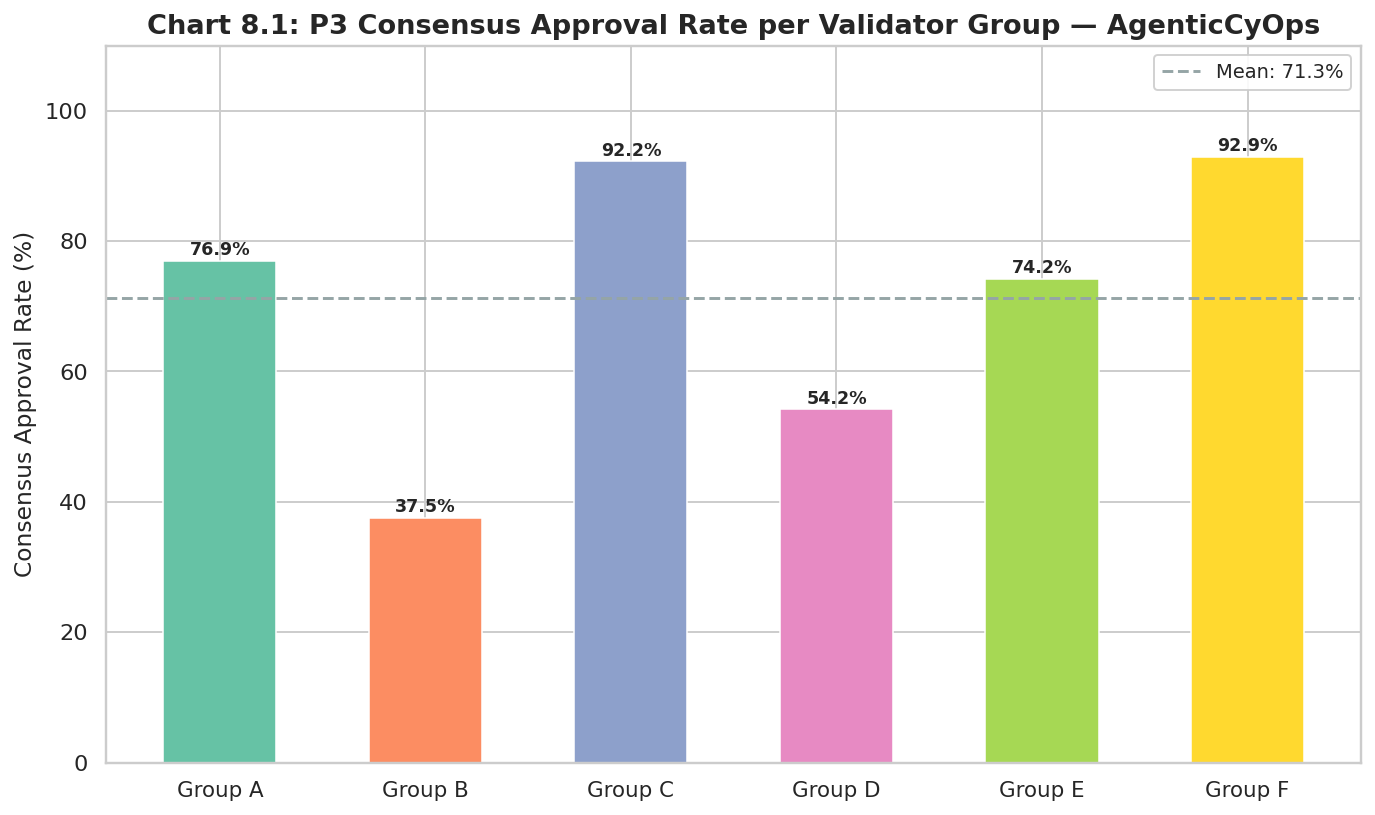

In [20]:
# Chart 8.1: Grouped bar — Consensus approval rate per group (A-F) for agenticcyops
aco = df[df["config"] == "agenticcyops"].copy()
aco["total_consensus"] = aco["p3_approved"] + aco["p3_rejected"]
aco["approval_rate"] = aco.apply(
    lambda r: r["p3_approved"] / r["total_consensus"] * 100 if r["total_consensus"] > 0 else 100, axis=1
)

group_approval = aco.groupby("group")["approval_rate"].mean().reindex(GROUPS)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(GROUPS))
palette = sns.color_palette("Set2", len(GROUPS))
bars = ax.bar(x, group_approval.values, 0.55, color=palette, edgecolor="white", linewidth=0.8)
_bar_labels(ax, bars, fmt="{:.1f}%")

ax.set_xticks(x)
ax.set_xticklabels([f"Group {g}" for g in GROUPS], fontsize=11)
ax.set_ylabel("Consensus Approval Rate (%)")
ax.set_title("Chart 8.1: P3 Consensus Approval Rate per Validator Group — AgenticCyOps",
             fontsize=14, fontweight="bold")
ax.set_ylim(0, 110)
ax.axhline(y=group_approval.mean(), color="#95a5a6", linestyle="--", linewidth=1.5,
           label=f"Mean: {group_approval.mean():.1f}%")
ax.legend(frameon=True, framealpha=0.9)
plt.tight_layout()
plt.show()

## Section 9: Key Findings Summary

In [21]:
# Auto-compute key findings
aco = df[df["config"] == "agenticcyops"]
flat = df[df["config"] == "flat"]
acl = df[df["config"] == "acl_hardened"]

# 1. Principle layers activated
def count_active_principles(sub):
    """Count how many of P1-P5 have any activity."""
    p_cols = {
        1: ["p1_identity_checks", "p1_response_checks", "p1_config_checks"],
        2: ["p2_manifest_checks", "p2_parameter_checks", "p2_output_checks"],
        3: ["p3_total_validations", "p3_chain_events", "p3_operational_events", "p3_replay_events"],
        4: ["p4_write_validations", "p4_schema_checks", "p4_metadata_checks"],
        5: ["p5_read_validations", "p5_field_filter_events", "p5_query_scope_events"],
    }
    active = 0
    for pnum, cols in p_cols.items():
        existing = [c for c in cols if c in sub.columns]
        if existing and sub[existing].sum().sum() > 0:
            active += 1
    return active

aco_active = count_active_principles(aco)
flat_active = count_active_principles(flat)

# 2. Average FP rate
avg_fp = aco["total_fp_rate"].mean() * 100

# 3. Latency comparison
avg_latency_aco = aco["e2e_latency_s"].mean()
avg_latency_flat = flat["e2e_latency_s"].mean()
latency_ratio = avg_latency_aco / avg_latency_flat if avg_latency_flat > 0 else 0

# 4. Token comparison
avg_tokens_aco = aco["total_tokens"].mean()
avg_tokens_flat = flat["total_tokens"].mean()
token_reduction = (1 - avg_tokens_aco / avg_tokens_flat) * 100 if avg_tokens_flat > 0 else 0

# 5. Attack surface reduction
avg_flat_tools = np.mean([TOOL_MANIFEST[d]["total"] for d in DOMAINS])
avg_aco_tools = aco["tools_visible_per_agent"].mean()

# Build markdown
findings = f"""### Computed Key Findings

- **Principle layer activation:** AgenticCyOps activates **{aco_active} principle layers** vs **{flat_active}** for flat
- **Average FP rate:** **{avg_fp:.2f}%** ({"BELOW" if avg_fp < 30 else "ABOVE"} 30% critical threshold)
- **Latency overhead:** AgenticCyOps avg **{avg_latency_aco/60:.1f} min** vs flat **{avg_latency_flat:.1f}s** ({latency_ratio:.1f}x increase)
- **Token efficiency:** AgenticCyOps uses **{token_reduction:.1f}% {"fewer" if token_reduction > 0 else "more"}** tokens than flat ({avg_tokens_aco:.0f} vs {avg_tokens_flat:.0f} avg)
- **P2 manifest scoping:** Reduces visible tools from **{avg_flat_tools:.0f}** to **{avg_aco_tools:.1f}** per phase-agent
- **Phases completed:** All configurations complete **4/4 phases** (100% task completion rate)
- **Consensus coverage:** AgenticCyOps averages **{aco["p3_consensus_votes"].mean():.1f}** consensus votes per run across {aco["group"].nunique()} validator groups
"""

from IPython.display import Markdown, display
display(Markdown(findings))

### Computed Key Findings

- **Principle layer activation:** AgenticCyOps activates **5 principle layers** vs **1** for flat
- **Average FP rate:** **13.07%** (BELOW 30% critical threshold)
- **Latency overhead:** AgenticCyOps avg **3.6 min** vs flat **61.1s** (3.5x increase)
- **Token efficiency:** AgenticCyOps uses **34.5% fewer** tokens than flat (10840 vs 16561 avg)
- **P2 manifest scoping:** Reduces visible tools from **14** to **3.4** per phase-agent
- **Phases completed:** All configurations complete **4/4 phases** (100% task completion rate)
- **Consensus coverage:** AgenticCyOps averages **20.8** consensus votes per run across 6 validator groups
